In [32]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon
import utils
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu, wilcoxon


subjects = ['485', '486', '487', '488', '489', '496', '497', '498', '499', '505', '5107', '515', '520', '538', '545']
controls = ['394', '396', '398', '400', '402', '404', '405', '406', '414', '415', '416', '417', '422'] # noisy- '423', '426', '429'
stim_side = {'485': 'R', '486': 'L', '487': 'R', '488': 'L', '489': 'R', '496': 'R', '497': 'R', '498': 'L', '499': 'L', '505': 'L', '5101': 'R', '5107': 'R', '515': 'R', '520': 'R', '538': 'R', '541': 'L', '544':'R', '545': 'R'}
frontal_chans = [f"{side}{string}{number}" for string in ['OF', 'AC', 'AF', 'FA', 'IF-dAC', 'OPR'] for number in range(1, 9) for side in ['R', 'L']]
temporal_chans = [f"{string}{number}" for string in ['RA', 'LA', 'RAH', 'LAH', 'RMH', 'LMH', 'REC', 'LEC', 'RPHG', 'LPHG'] for number in range(1, 9)]
temporal_soz = ['485', '487', '488', '489', '496', '497', '498', '515', '520', '538', '541', '544']
frontal_soz = ['486', '499', '505', '5101', '5107', '545']
soz_side = {'485': 'R', '486': 'R', '487': 'L', '488': 'R', '489': 'L', '496': 'R', '497': 'B', '498': 'B', '499': 'R', '505': 'L', '5101': 'L', '5107': 'L', '515': 'R', '520': 'B', '538': 'L', '541': 'B', '544':'L', '545': 'L'}
temporal_stim = ['489', '496', '538']

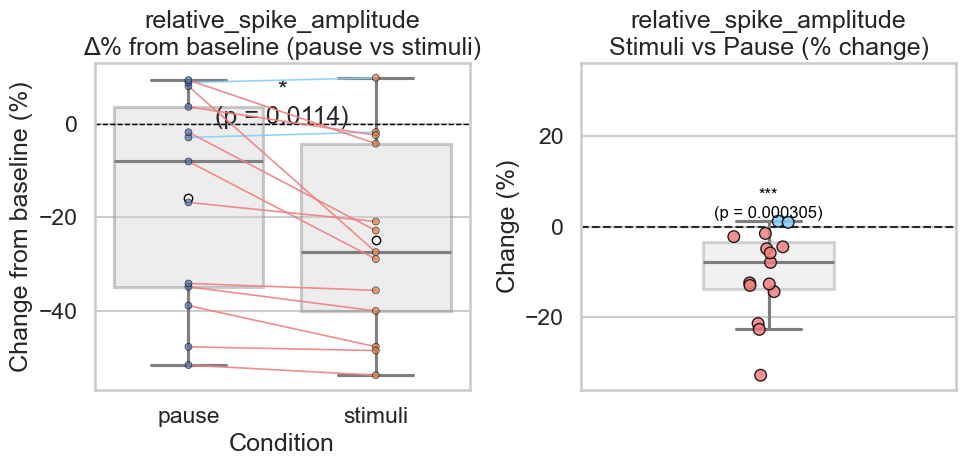

In [18]:
# first from each group
# ----------------------------------------------------
# הגדרות משתמש
# ----------------------------------------------------
subject_ids = [x for x in subjects if x not in ['5101','541', '544']]
base_path = r"D:\Ofer_backup\V6_model"

features = ["amplitude", "relative_spike_duration", "group_event_size", "relative_spike_amplitude", "group_event_spatial_spread", "angle"]
timestamp_col = "timestamp"

baseline_cond   = "before_first_stimuli_session"
condition_order = ["pause_block", "stimuli_block"]
condition_labels = {"pause_block": "pause", "stimuli_block": "stimuli"}

target_param = "relative_spike_amplitude"  # הפיצ'ר להצגה בשני הגרפים

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

# ----------------------------------------------------
# קריאה + ניקוי + ממוצע לכל מצב לכל נבדק (פעם אחת)
# ----------------------------------------------------
all_data = []

for subj in subject_ids:
    feat_path = os.path.join(
        base_path, f"p{subj}", "unichannel_model", "min_amplitude_1",
        "features", f"p{subj}_flat_features.csv"
    )
    if not os.path.exists(feat_path):
        print(f"Missing feature file for subject {subj}")
        continue

    df = pd.read_csv(feat_path)

    cols = ["stimuli_flag", "hypnogram_flag", "channel", "group", timestamp_col] + features
    df = df[cols].copy()

    # רק NREM
    df = df[df["hypnogram_flag"] == "nrem"]
    df = df.drop_duplicates(subset="group", keep="first")


    # סינון ארטיפקטים
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    df = utils.remove_noisy_samples_and_channels(
        subj, df, ann_path, ts_col="timestamp", channel_col="channel"
    )

    df["subject_id"] = subj

    # ממוצע לכל מצב לכל נבדק
    subj_avg = df.groupby(["subject_id", "stimuli_flag"], as_index=False)[features].mean()
    all_data.append(subj_avg)

data = pd.concat(all_data, ignore_index=True)

# ----------------------------------------------------
# חישוב 1: Δ% מהבייסליין (כמו בקוד הראשון)
# ----------------------------------------------------
df_melt = data.melt(
    id_vars=["subject_id", "stimuli_flag"],
    value_vars=features,
    var_name="Parameter",
    value_name="Value"
)

baseline = (
    df_melt[df_melt["stimuli_flag"] == baseline_cond]
    [["subject_id", "Parameter", "Value"]]
    .rename(columns={"Value": "Baseline"})
)

df_melt = df_melt.merge(baseline, on=["subject_id", "Parameter"], how="left")
df_melt = df_melt[df_melt["Baseline"].notna() & (df_melt["Baseline"] != 0)].copy()
df_melt["Value_pct"] = (df_melt["Value"] - df_melt["Baseline"]) / df_melt["Baseline"] * 100

# ----------------------------------------------------
# חישוב 2: % שינוי Stimuli לעומת Pause (כמו בקוד השני)
# ----------------------------------------------------
data_ps = data[data["stimuli_flag"].isin(condition_order)].copy()
df_pivot = data_ps.pivot(index="subject_id", columns="stimuli_flag", values=features)  # MultiIndex columns

pct_change_df = pd.DataFrame(index=df_pivot.index)
for feat in features:
    val_pause = df_pivot[(feat, "pause_block")]
    val_stim  = df_pivot[(feat, "stimuli_block")]

    ok = val_pause.notna() & (val_pause != 0) & val_stim.notna()
    pct_change_df.loc[ok, feat] = ((val_stim[ok] - val_pause[ok]) / val_pause[ok]) * 100

df_plot = pct_change_df.melt(var_name="Parameter", value_name="Percent_Change", ignore_index=False).reset_index()

# ----------------------------------------------------
# ויזואליזציה: שני גרפים אחד ליד השני
# ----------------------------------------------------
sns.set(style="whitegrid", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# ========== גרף שמאל: Pause vs Stimuli על ציר Δ% מהבייסליין ==========
df_left = df_melt[
    (df_melt["Parameter"] == target_param) &
    (df_melt["stimuli_flag"].isin(condition_order))
].copy()

ax1.axhline(0, color="black", linestyle="--", linewidth=1)

sns.boxplot(
    data=df_left,
    x="stimuli_flag",
    y="Value_pct",
    order=condition_order,
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"},
    fliersize=2,
    color="lightgray",
    boxprops=dict(alpha=0.4),
    zorder=1,
    ax=ax1
)

wide_left = df_left.pivot(index="subject_id", columns="stimuli_flag", values="Value_pct").reindex(columns=condition_order)
wide_left_clean = wide_left.dropna()

# paired t-test (stim vs pause)
if len(wide_left_clean) >= 2:
    pause_vals = wide_left_clean["pause_block"].values
    stim_vals  = wide_left_clean["stimuli_block"].values
    t_stat, p_t = ttest_rel(stim_vals, pause_vals)
    ax1.text(0.5, 0.95, f"{p_to_stars(p_t)}\n(p = {p_t:.3g})",
             transform=ax1.transAxes, ha="center", va="top")

# קווים מחברים לכל נבדק
x_positions = np.arange(len(condition_order))
for subj, row in wide_left.iterrows():
    y = row.values.astype(float)
    mask = ~np.isnan(y)
    xs = x_positions[mask]
    ys = y[mask]
    if len(ys) < 2:
        continue

    slope = ys[-1] - ys[0]
    line_color = "lightskyblue" if slope > 0 else ("lightcoral" if slope < 0 else "lightgray")
    ax1.plot(xs, ys, color=line_color, alpha=0.9, linewidth=1.2, zorder=3)

sns.stripplot(
    data=df_left,
    x="stimuli_flag",
    y="Value_pct",
    order=condition_order,
    jitter=False,
    linewidth=0.5,
    edgecolor="black",
    alpha=0.7,
    size=5,
    zorder=4,
    ax=ax1
)

ax1.set_title(f"{target_param}\nΔ% from baseline (pause vs stimuli)")
ax1.set_xlabel("Condition")
ax1.set_ylabel("Change from baseline (%)")
ax1.set_xticklabels([condition_labels[c] for c in condition_order])

# ========== גרף ימין: Stimuli vs Pause %Change מול 0 ==========
df_right = df_plot[df_plot["Parameter"] == target_param].copy()
values = df_right["Percent_Change"].dropna()

ax2.axhline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.8)

# Boxplot (עמודה אחת)
sns.boxplot(
    y=values,
    width=0.35,
    color="lightgray",
    boxprops=dict(alpha=0.3),
    showfliers=False,
    ax=ax2
)

# נקודות בצביעה לפי סימן (matplotlib, כדי להימנע מטריקים של seaborn)
rng = np.random.default_rng(0)
x_jitter = rng.normal(loc=0.0, scale=0.04, size=len(values))
colors = np.where(values > 0, "lightskyblue", "lightcoral")
ax2.scatter(x_jitter, values, s=70, c=colors, edgecolors="black", linewidths=1, alpha=0.85, zorder=3)

# Wilcoxon מול 0
if len(values) >= 1:
    stat, p_val = wilcoxon(values)  # signed-rank vs 0
    stars = p_to_stars(p_val)
    y_max = float(np.nanmax(values)) if len(values) else 1.0
    ax2.text(0, y_max + (abs(y_max) * 0.12 + 1e-6), f"{stars}\n(p = {p_val:.3g})",
             ha="center", va="bottom", fontsize=12, color="black")

# גבולות יפים סימטריים
if len(values) > 0:
    limit = max(abs(values.min()), abs(values.max())) * 1.1
    ax2.set_ylim(-limit, limit)

ax2.set_title(f"{target_param}\nStimuli vs Pause (% change)")
ax2.set_ylabel("Change (%)")
ax2.set_xlabel("")
ax2.set_xticks([])

plt.tight_layout()
plt.show()


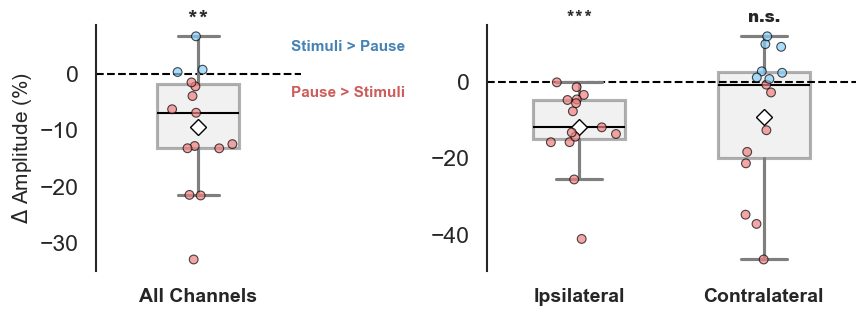

In [36]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import utils

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

def compute_pct_change_pause_vs_stim(data, index_cols, feats):
    cond_order = ["pause_block", "stimuli_block"]
    data_ps = data[data["stimuli_flag"].isin(cond_order)].copy()
    
    # וידוא שאין כפילויות לפני הפיבוט
    data_ps = data_ps.groupby(index_cols + ["stimuli_flag"])[feats].mean().reset_index()
    
    df_pivot = data_ps.pivot(index=index_cols, columns="stimuli_flag", values=feats)
    pct_change_df = pd.DataFrame(index=df_pivot.index)
    
    for feat in feats:
        val_pause = df_pivot[(feat, "pause_block")]
        val_stim  = df_pivot[(feat, "stimuli_block")]
        ok = val_pause.notna() & (val_pause != 0) & val_stim.notna()
        pct_change_df.loc[ok, feat] = ((val_stim[ok] - val_pause[ok]) / val_pause[ok]) * 100
        
    return pct_change_df.melt(var_name="Parameter", value_name="Percent_Change", ignore_index=False).reset_index()

# ----------------------------------------------------
# 1. עיבוד נתונים (כולל תיקון NREM והסרת כפילויות)
# ----------------------------------------------------
all_data_lat = [] # עבור הגרף הימני (Ipsi/Contra)
all_data_all = [] # עבור הגרף השמאלי (All Channels - משוקלל נכון)
subject_ids_to_run = [x for x in subjects if x not in ['5101','541', '544']]

for subj in subject_ids_to_run:
    feat_path = os.path.join(base_path, f"p{subj}", "unichannel_model", "min_amplitude_1", "features", f"p{subj}_flat_features.csv")
    if not os.path.exists(feat_path): continue
    
    df = pd.read_csv(feat_path)
    
    # חובה: סינון NREM והסרת כפילויות כדי לשמור על עקביות
    # df = df[df["hypnogram_flag"] == "nrem"].copy() 
    df = df.drop_duplicates(subset="group", keep="first")
    
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    try:
        df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")
    except: continue
    
    df["subject_id"] = subj
    stim = stim_side.get(str(subj))
    df["chan_side"] = df["channel"].astype(str).str[0]
    
    # סינון לערוצים רלוונטיים (R/L)
    df_lat = df[df["chan_side"].isin(["R", "L"])].copy()
    
    if stim:
        # 1. חישוב עבור הגרף המפוצל (הממוצע נשמר לפי lat_group)
        df_lat["lat_group"] = np.where(df_lat["chan_side"] == stim, "ipsi", "contra")
        subj_avg_lat = df_lat.groupby(["subject_id", "stimuli_flag", "lat_group"], as_index=False)[[target_param]].mean()
        all_data_lat.append(subj_avg_lat)
        
        # 2. חישוב עבור הגרף המאוחד (מתעלמים מהצד, כל הערוצים מקבלים משקל שווה בממוצע)
        subj_avg_all = df_lat.groupby(["subject_id", "stimuli_flag"], as_index=False)[[target_param]].mean()
        all_data_all.append(subj_avg_all)

# איחוד הנתונים בנפרד
data_lat_combined = pd.concat(all_data_lat, ignore_index=True)
data_all_combined = pd.concat(all_data_all, ignore_index=True)

# חישוב אחוז השינוי על אובייקטים נפרדים
df_plot_lat = compute_pct_change_pause_vs_stim(data_lat_combined, ["subject_id", "lat_group"], [target_param])
df_plot_all = compute_pct_change_pause_vs_stim(data_all_combined, ["subject_id"], [target_param])
# ----------------------------------------------------
# ויזואליזציה מאוחדת: לייבלים נקיים וסטטיסטיקה מיושרת
# ----------------------------------------------------
sns.set(style="white", context="talk")

# יצירת Figure עם צירים עצמאיים
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), sharey=False, gridspec_kw={'width_ratios': [1, 1.8]})

# --- גרף שמאל: All Channels ---
vals_all = df_plot_all[df_plot_all["Parameter"] == target_param]["Percent_Change"].dropna()
ax1.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

sns.boxplot(y=vals_all, width=0.4, color="lightgray", showmeans=True, ax=ax1,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8},
            boxprops=dict(alpha=0.3, edgecolor="black"), medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

rng1 = np.random.default_rng(3)
xj1 = rng1.normal(loc=0.0, scale=0.05, size=len(vals_all))
ax1.scatter(xj1, vals_all, s=40, c=np.where(vals_all > 0, "lightskyblue", "lightcoral"), 
            edgecolors="black", linewidths=0.8, alpha=0.7, zorder=3)

# סטטיסטיקה (ax1)
_, p_all = wilcoxon(vals_all)
y_max_all = vals_all.max()
ax1.text(0, y_max_all + abs(y_max_all)*0.2, f"{p_to_stars(p_all)}", ha="center", va="bottom", fontsize=15, fontweight='heavy')

# לייבלים וכיתובים כיווניים (רק בגרף השמאלי)
ax1.set_xticks([0])
ax1.set_xticklabels(["All Channels"], fontsize=14, fontweight='bold')
curr_ylim1 = ax1.get_ylim()
ax1.text(0.45, 4, "Stimuli > Pause", color="steelblue", fontsize=11, fontweight='bold', ha='left')
ax1.text(0.45, -4, "Pause > Stimuli", color="indianred", fontsize=11, fontweight='bold', ha='left')

# --- גרף ימין: By Laterality (Ipsi/Contra) ---
df_plot_final = df_plot_lat[df_plot_lat["Parameter"] == target_param].copy()
lat_order = ["ipsi", "contra"]
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

sns.boxplot(data=df_plot_final, x="lat_group", y="Percent_Change", order=lat_order, width=0.5, color="lightgray", 
            showmeans=True, ax=ax2, meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8},
            boxprops=dict(alpha=0.3, edgecolor="black"), medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

# חישוב גובה אחיד לכוכביות בגרף הימני
y_max_lat = df_plot_final[df_plot_final["lat_group"].isin(lat_order)]["Percent_Change"].max()
star_y_lat = y_max_lat + abs(y_max_lat)*0.25


for i, grp in enumerate(lat_order):
    vals = df_plot_final[df_plot_final["lat_group"] == grp]["Percent_Change"].dropna().values
    rng2 = np.random.default_rng(3 + i)
    xj2 = rng2.normal(loc=i, scale=0.06, size=len(vals))
    ax2.scatter(xj2, vals, s=40, c=np.where(vals > 0, "lightskyblue", "lightcoral"), 
                edgecolors="black", linewidths=0.8, alpha=0.7, zorder=3)
    
    _, p_v = wilcoxon(vals)
    # שימוש ב-star_y_lat האחיד לשני הבוקסים
    ax2.text(i, star_y_lat, f"{p_to_stars(p_v)}", ha="center", va="bottom", fontsize=12, fontweight='heavy')

ax2.set_xlabel("")
ax2.set_xticklabels(["Ipsilateral", "Contralateral"], fontsize=14, fontweight='bold')

# --- עיצוב סופי ---
for ax_obj in [ax1, ax2]:
    for spine in ['top', 'right', 'bottom']: ax_obj.spines[spine].set_visible(False)
    ax_obj.spines['left'].set_linewidth(1.5)

ax1.set_ylabel("$\Delta$ Amplitude (%)", fontsize=15)
ax2.set_ylabel("")

plt.tight_layout()
# plt.savefig('combined_amplitude_plots.pdf')

plt.show()

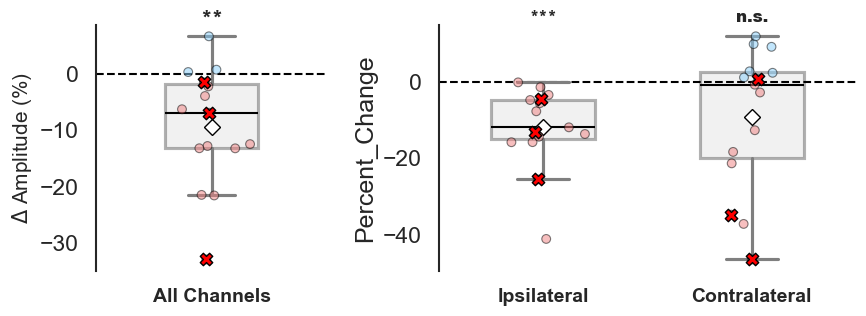

In [8]:
# ----------------------------------------------------
# 1. הכנת הנתונים הסופיים לציור
# ----------------------------------------------------
temporal_stim = ['489', '496', '538']

# גרף שמאל (All Channels)
df_plot_all_final = df_plot_all[df_plot_all["Parameter"] == target_param].copy()
df_plot_all_final['is_temporal'] = df_plot_all_final['subject_id'].astype(str).isin(temporal_stim)

# גרף ימין (Laterality)
df_plot_lat_final = df_plot_lat[df_plot_lat["Parameter"] == target_param].copy()
df_plot_lat_final['is_temporal'] = df_plot_lat_final['subject_id'].astype(str).isin(temporal_stim)

# ----------------------------------------------------
# 2. ויזואליזציה מאוחדת
# ----------------------------------------------------
sns.set(style="white", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), sharey=False, gridspec_kw={'width_ratios': [1, 1.8]})

# --- גרף שמאל: All Channels ---
vals_all_df = df_plot_all_final.dropna(subset=["Percent_Change"])
vals_all = vals_all_df["Percent_Change"].values
is_temp_all = vals_all_df["is_temporal"].values

ax1.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

sns.boxplot(y=vals_all, width=0.4, color="lightgray", showmeans=True, ax=ax1,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8},
            boxprops=dict(alpha=0.3, edgecolor="black"), medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

rng1 = np.random.default_rng(3)
xj1 = rng1.normal(loc=0.0, scale=0.05, size=len(vals_all))

# נקודות רגילות
ax1.scatter(xj1, vals_all, s=40, c=np.where(vals_all > 0, "lightskyblue", "lightcoral"), 
            edgecolors="black", linewidths=0.8, alpha=0.5, zorder=3)

# הדגשת Temporal ב-X אדום
if is_temp_all.any():
    ax1.scatter(xj1[is_temp_all], vals_all[is_temp_all], s=80, c="red", 
                marker="X", edgecolors="black", linewidths=1, zorder=5)

# סטטיסטיקה (ax1)
_, p_all = wilcoxon(vals_all)
y_max_all = vals_all.max()
ax1.text(0, y_max_all + abs(y_max_all)*0.2, f"{p_to_stars(p_all)}", ha="center", va="bottom", fontsize=15, fontweight='heavy')
ax1.set_xticks([0])
ax1.set_xticklabels(["All Channels"], fontsize=14, fontweight='bold')

# --- גרף ימין: By Laterality (Ipsi/Contra) ---
lat_order = ["ipsi", "contra"]
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

sns.boxplot(data=df_plot_lat_final, x="lat_group", y="Percent_Change", order=lat_order, width=0.5, color="lightgray", 
            showmeans=True, ax=ax2, meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8},
            boxprops=dict(alpha=0.3, edgecolor="black"), medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

y_max_lat = df_plot_lat_final["Percent_Change"].max()
star_y_lat = y_max_lat + abs(y_max_lat)*0.25

for i, grp in enumerate(lat_order):
    group_data = df_plot_lat_final[df_plot_lat_final["lat_group"] == grp].dropna(subset=["Percent_Change"])
    vals = group_data["Percent_Change"].values
    is_temp = group_data["is_temporal"].values
    
    rng2 = np.random.default_rng(3 + i)
    xj2 = rng2.normal(loc=i, scale=0.06, size=len(vals))
    
    # נקודות רגילות
    ax2.scatter(xj2, vals, s=40, c=np.where(vals > 0, "lightskyblue", "lightcoral"), 
                edgecolors="black", linewidths=0.8, alpha=0.5, zorder=3)
    
    # הדגשת Temporal ב-X אדום
    if is_temp.any():
        ax2.scatter(xj2[is_temp], vals[is_temp], s=80, c="red", 
                    marker="X", edgecolors="black", linewidths=1, zorder=5)
    
    _, p_v = wilcoxon(vals)
    ax2.text(i, star_y_lat, f"{p_to_stars(p_v)}", ha="center", va="bottom", fontsize=12, fontweight='heavy')

ax2.set_xlabel("")
ax2.set_xticklabels(["Ipsilateral", "Contralateral"], fontsize=14, fontweight='bold')

# --- עיצוב סופי ---
ax1.set_ylabel("$\Delta$ Amplitude (%)", fontsize=15)
for ax_obj in [ax1, ax2]:
    for spine in ['top', 'right', 'bottom']: ax_obj.spines[spine].set_visible(False)
    ax_obj.spines['left'].set_linewidth(1.5)

plt.tight_layout()
plt.show()

--- Statistics ---
All Channels: p = 0.001312
Ipsi: p = 0.000031
Contra: p = 0.103882


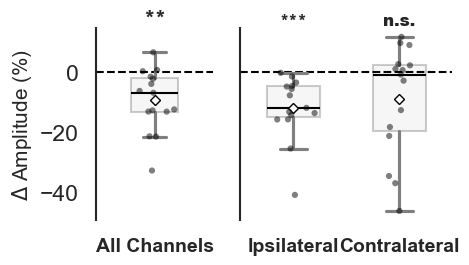

In [35]:
# ----------------------------------------------------
# ויזואליזציה מאוחדת: לייבלים נקיים וסטטיסטיקה מיושרת (ציר Y משותף)
# ----------------------------------------------------
sns.set(style="white", context="talk")

# שינוי יחיד: הוספת sharey=True כדי שהצירים יהיו באותו טווח
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 3), sharey=True, gridspec_kw={'width_ratios': [1, 1.8]})

# --- גרף שמאל: All Channels ---
vals_all = df_plot_all[df_plot_all["Parameter"] == target_param]["Percent_Change"].dropna()
ax1.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

sns.boxplot(y=vals_all, width=0.4, color="lightgray", showmeans=True, ax=ax1,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":5},
                        boxprops=dict(alpha=0.2, edgecolor="black", linewidth=1.5), medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

# שינוי צבע ל-black, שקיפות alpha=0.5 וגודל מעט קטן יותר
rng1 = np.random.default_rng(3)
xj1 = rng1.normal(loc=0.0, scale=0.05, size=len(vals_all))
ax1.scatter(xj1, vals_all, s=20, c="black", alpha=0.5, edgecolors="none", zorder=3)

# סטטיסטיקה (ax1) - חישוב גובה אחיד לפי המקסימום הגלובלי של שני הגרפים
global_max = max(df_plot_all["Percent_Change"].max(), df_plot_lat["Percent_Change"].max())
star_y_fixed = global_max + abs(global_max)*0.25

_, p_all = wilcoxon(vals_all, alternative='less')
ax1.text(0, star_y_fixed, f"{p_to_stars(p_all)}", ha="center", va="bottom", fontsize=15, fontweight='heavy')

# לייבלים וכיתובים כיווניים
ax1.set_xticks([0])
ax1.set_xticklabels(["All Channels"], fontsize=14, fontweight='bold')

# --- גרף ימין: By Laterality (Ipsi/Contra) ---
df_plot_final = df_plot_lat[df_plot_lat["Parameter"] == target_param].copy()
lat_order = ["ipsi", "contra"]
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

sns.boxplot(data=df_plot_final, x="lat_group", y="Percent_Change", order=lat_order, width=0.5, color="lightgray", 
            showmeans=True, ax=ax2, meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":5},
            boxprops=dict(alpha=0.2, edgecolor="black", linewidth=1.5), medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

print(f"--- Statistics ---\nAll Channels: p = {p_all:.6f}")

for i, grp in enumerate(lat_order):
    vals = df_plot_final[df_plot_final["lat_group"] == grp]["Percent_Change"].dropna().values
    
    # שינוי צבע ל-black, שקיפות alpha=0.5 וגודל מעט קטן יותר
    rng2 = np.random.default_rng(3 + i)
    xj2 = rng2.normal(loc=i, scale=0.06, size=len(vals))
    ax2.scatter(xj2, vals, s=20, c="black", alpha=0.5, edgecolors="none", zorder=3)
    
    _, p_v = wilcoxon(vals, alternative='less')
    # שימוש ב-star_y_fixed האחיד
    ax2.text(i, star_y_fixed, f"{p_to_stars(p_v)}", ha="center", va="bottom", fontsize=12, fontweight='heavy')
    print(f"{grp.capitalize()}: p = {p_v:.6f}")

ax2.set_xlabel("")
ax2.set_xticklabels(["Ipsilateral", "Contralateral"], fontsize=14, fontweight='bold')

# --- עיצוב סופי ---
for ax_obj in [ax1, ax2]:
    for spine in ['top', 'right', 'bottom']: ax_obj.spines[spine].set_visible(False)
    ax_obj.spines['left'].set_linewidth(1.5)

ax1.set_ylabel("$\Delta$ Amplitude (%)", fontsize=15)
ax2.set_ylabel("")

plt.tight_layout()
plt.savefig('combined_amplitude_plots.pdf')
plt.show()

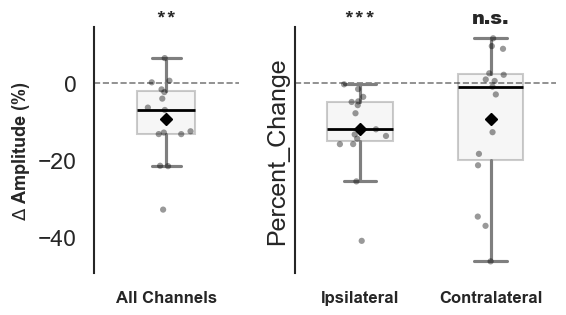

In [130]:
# --- שיפורים אסתטיים סופיים ---
sns.set(style="white", context="talk")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True, gridspec_kw={'width_ratios': [1, 1.8]})

# פונקציה עזר להסרת שנתות מיותרות
def clean_ax(ax_obj):
    for spine in ['top', 'right', 'bottom']:
        ax_obj.spines[spine].set_visible(False)
    ax_obj.spines['left'].set_linewidth(1.5)
    ax_obj.tick_params(axis='x', which='both', bottom=False) # הסרת הקווים הקטנים למטה

# --- גרף שמאל: All Channels ---
ax1.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.5, zorder=1)
sns.boxplot(y=vals_all, width=0.4, color="lightgray", showmeans=True, ax=ax1,
            meanprops={"marker":"D", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":6},
            boxprops=dict(alpha=0.2, edgecolor="black", linewidth=1.5), 
            medianprops=dict(color="black", linewidth=2), 
            showfliers=False, zorder=2)

xj1 = np.random.default_rng(3).normal(0, 0.05, size=len(vals_all))
ax1.scatter(xj1, vals_all, s=20, c="black", alpha=0.4, edgecolors="none", zorder=3)

ax1.text(0, star_y_fixed, f"{p_to_stars(p_all)}", ha="center", va="bottom", fontsize=14, fontweight='heavy')
ax1.set_xticks([0])
ax1.set_xticklabels(["All Channels"], fontsize=12, fontweight='bold')
clean_ax(ax1)

# --- גרף ימין: By Laterality ---
ax2.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.5, zorder=1)
sns.boxplot(data=df_plot_final, x="lat_group", y="Percent_Change", order=lat_order, width=0.5, color="lightgray", 
            showmeans=True, ax=ax2, 
            meanprops={"marker":"D", "markerfacecolor":"black", "markeredgecolor":"black", "markersize":6},
            boxprops=dict(alpha=0.2, edgecolor="black", linewidth=1.5), 
            medianprops=dict(color="black", linewidth=2), 
            showfliers=False, zorder=2)

for i, grp in enumerate(lat_order):
    vals = df_plot_final[df_plot_final["lat_group"] == grp]["Percent_Change"].dropna().values
    xj2 = np.random.default_rng(3 + i).normal(i, 0.06, size=len(vals))
    ax2.scatter(xj2, vals, s=20, c="black", alpha=0.4, edgecolors="none", zorder=3)
    
    _, p_v = wilcoxon(vals)
    ax2.text(i, star_y_fixed, f"{p_to_stars(p_v)}", ha="center", va="bottom", fontsize=14, fontweight='heavy')

ax2.set_xlabel("")
ax2.set_xticklabels(["Ipsilateral", "Contralateral"], fontsize=12, fontweight='bold')
clean_ax(ax2)

ax1.set_ylabel("$\Delta$ Amplitude (%)", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

All Channels: p = 0.002625
Ipsilateral: p = 0.000061
Contralateral: p = 0.207764


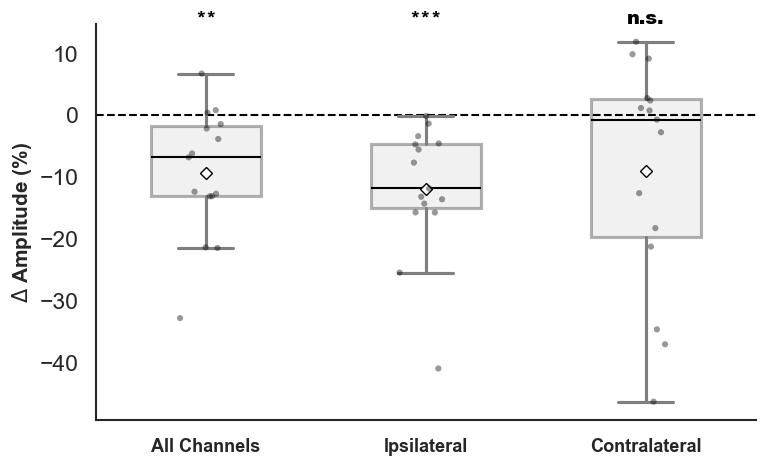

In [113]:
# ----------------------------------------------------
# 1. הכנת הנתונים המאוחדים לגרף אחד
# ----------------------------------------------------
# הכנת הנתונים מהגרף המאוחד (All)
df_all_for_union = df_plot_all[df_plot_all["Parameter"] == target_param].copy()
df_all_for_union["group"] = "All Channels"

# הכנת הנתונים מהגרף המפוצל (Ipsi/Contra)
df_lat_for_union = df_plot_lat[df_plot_lat["Parameter"] == target_param].copy()
df_lat_for_union["group"] = df_lat_for_union["lat_group"].map({"ipsi": "Ipsilateral", "contra": "Contralateral"})

# איחוד ל-DataFrame אחד
df_final_unified = pd.concat([df_all_for_union, df_lat_for_union], ignore_index=True)
order = ["All Channels", "Ipsilateral", "Contralateral"]

# ----------------------------------------------------
# 2. ויזואליזציה - גרף אחד מאוחד
# ----------------------------------------------------
sns.set(style="white", context="talk")
fig, ax = plt.subplots(figsize=(8, 5))

# קו אפס
ax.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

# ציור Boxplot
sns.boxplot(data=df_final_unified, x="group", y="Percent_Change", order=order, 
            width=0.5, color="lightgray", showmeans=True, ax=ax,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6},
            boxprops=dict(alpha=0.3, edgecolor="black"), 
            medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

# חישוב גובה לכוכביות
y_max = df_final_unified["Percent_Change"].max()
star_y = y_max + abs(y_max) * 0.2

# הוספת נקודות (Stripplot ידני עם Jitter) וסטטיסטיקה
for i, grp_name in enumerate(order):
    vals = df_final_unified[df_final_unified["group"] == grp_name]["Percent_Change"].dropna().values
    
    # נקודות שחורות, קטנות ושקופות
    rng = np.random.default_rng(42 + i)
    xj = rng.normal(loc=i, scale=0.06, size=len(vals))
    ax.scatter(xj, vals, s=20, c="black", alpha=0.4, edgecolors="none", zorder=3)
    
    # חישוב Wilcoxon
    _, p_v = wilcoxon(vals)
    ax.text(i, star_y, f"{p_to_stars(p_v)}", ha="center", va="bottom", 
            fontsize=14, fontweight='heavy', color="black")
    
    print(f"{grp_name}: p = {p_v:.6f}")

# --- עיצוב סופי ---
ax.set_xlabel("")
ax.set_ylabel("$\Delta$ Amplitude (%)", fontsize=15, fontweight='bold')
ax.set_xticklabels(order, fontsize=13, fontweight='bold')

# הסרת ספיינים מיותרים
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)


plt.tight_layout()
# plt.savefig('unified_amplitude_plot.pdf')
plt.show()

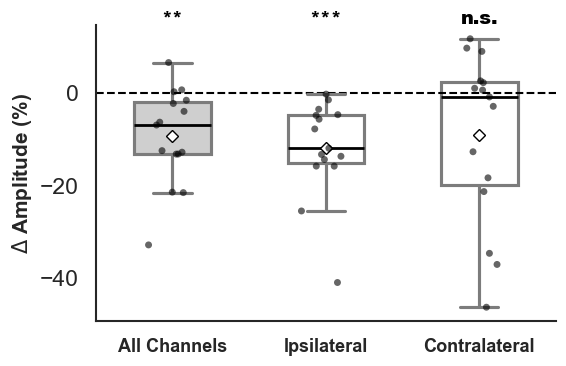

In [123]:
# --- ויזואליזציה - גרף מאוחד עם צבע דיפולטיבי ונקודות מודגשות ---
sns.set(style="white", context="talk")
fig, ax = plt.subplots(figsize=(6, 4))

# 1. קו אפס (אופקי)
ax.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

# 2. פלטת צבעים: השמאלי בצבע הדיפולטיבי של Seaborn, השאר בלבן
# sns.color_palette()[0] מחזיר את הכחול הסטנדרטי
palette = ['#cfcfcf', "#ffffff", "#ffffff"]

# ציור Boxplot
sns.boxplot(data=df_final_unified, x="group", y="Percent_Change", order=order, 
            palette=palette, width=0.5, showmeans=True, ax=ax,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6},
            medianprops=dict(color="black", linewidth=2), 
            showfliers=False, zorder=2)

# חישוב גובה לכוכביות
y_max = df_final_unified["Percent_Change"].max()
star_y = y_max + abs(y_max) * 0.2

# 3. הוספת נקודות וסטטיסטיקה
for i, grp_name in enumerate(order):
    vals = df_final_unified[df_final_unified["group"] == grp_name]["Percent_Change"].dropna().values
    
    # נקודות שחורות, גדולות יותר (s=25) וג'יטר רחב יותר (scale=0.08)
    rng = np.random.default_rng(42 + i)
    xj = rng.normal(loc=i, scale=0.08, size=len(vals))
    ax.scatter(xj, vals, s=25, c="black", alpha=0.6, edgecolors="none", zorder=3)
    
    # חישוב Wilcoxon
    _, p_v = wilcoxon(vals)
    ax.text(i, star_y, f"{p_to_stars(p_v)}", ha="center", va="bottom", 
            fontsize=14, fontweight='heavy', color="black")

# --- עיצוב סופי ---
ax.set_xlabel("")
ax.set_ylabel("$\Delta$ Amplitude (%)", fontsize=15, fontweight='bold')
ax.set_xticklabels(order, fontsize=13, fontweight='bold')

# הסרת ספיינים עליון וימני
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.show()

# time-related analysis

In [20]:
stim_side_right = ['485', '487', '489', '490', '496', '497', '5101', '5107', '515', '520', '538', '544', '545',
                       '396', '398', '404', '406', '415']
controls = ['394', '396', '398', '402', '404', '406', '415', '416', '417', '423']
plot_legend = ['all', 'ipsi', 'contra', 'frontal', 'temporal']
frontal_chans = [f"{side}{string}{number}" for string in ['OF', 'AC', 'AF', 'FA', 'IF-dAC', 'OPR'] for number in range(1, 9) for side in ['R', 'L']]
temporal_chans = [f"{string}{number}" for string in ['RA', 'LA', 'RAH', 'LAH', 'RMH', 'LMH', 'REC', 'LEC', 'RPHG', 'LPHG'] for number in range(1, 9)]
feat_path = r'D:\Ofer_backup\V6_model\p%s\unichannel_model\min_amplitude_1\features\p%s_flat_features.csv'
curr_run_subjects = subjects
is_control = curr_run_subjects == controls
for_avg_props = {}
for_avg_props_raw = {} 
baselines = [] 
base_relative = True

scaler = StandardScaler()
def get_subj_data(subj):
    df = pd.read_csv(feat_path % (subj, subj))

    # נוסיף גם timestamp + channel
    cols = ["timestamp", "channel", "amplitude", "duration", "group", "group_event_duration", "group_event_size",
            "group_event_deepest",
            "group_event_shallowest", "group_event_spatial_spread", "stimuli_flag", "hypnogram_flag", "angle",
            "relative_spike_amplitude", "relative_spike_duration"]
    df = df[cols].copy()

    # רק NREM
    # df = df[df["hypnogram_flag"] == "nrem"]
    df = df.drop_duplicates(subset="group", keep="first")

    # סינון דגימות מלוכלכות לפי קובץ הארטיפקטים של אותו נבדק
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")

    df["subject_id"] = subj
    return df


def init_dicts_with_baseline_rates(subj_features, nrem_start, stim_start, side):
    baseline_minutes = (stim_start - nrem_start) / 60
    baselines.append(baseline_minutes)
    # if there is no sleep before first stim (515, 545)
    # TODO: remove 515 and 545?! maybe avg across all
    if baseline_minutes < 0:
        # take 10 minutes before stimuli as baseline
        baseline = subj_features[(subj_features['timestamp'] > (stim_start - 10 * 60) * 1000) &
                                 (subj_features['timestamp'] < stim_start * 1000)]
        baseline_minutes = 10
    else:
        # take epochs after sleep onset but before first stimuli as baseline
        # baseline = subj_features[subj_features['stimuli_flag'] == 'before_first_stimuli_session']
        baseline = subj_features[(subj_features['stimuli_flag'] == 'before_first_stimuli_session') & (
                    subj_features['timestamp'] > nrem_start * 1000)]
    # נסדר לפי זמן כדי שה"שורה הראשונה" תהיה באמת הכי מוקדמת בזמן
    baseline = baseline.sort_values('timestamp')
    # לקחת שורה ראשונה לכל group
    baseline_groups = baseline.groupby('group', as_index=False).first()

    base_rate = len(baseline_groups) / baseline_minutes
    rates = {'all': [base_rate],
             'ipsi': [len(baseline_groups[baseline_groups['channel'].str[0] == side]) / baseline_minutes],
             'contra': [len(baseline_groups[baseline_groups['channel'].str[0] != side]) / baseline_minutes],
             'frontal': [len(baseline_groups[baseline_groups['channel'].isin(frontal_chans)]) / baseline_minutes],
             'temporal': [len(baseline_groups[baseline_groups['channel'].isin(temporal_chans)]) / baseline_minutes]}
    props = {'rates': rates}
    for prop in ['relative_spike_amplitude', 'relative_spike_duration', 'group_event_size',
                 'group_event_spatial_spread']:
        if 'group' in prop:
            baseline_prop = baseline_groups
        else:
            baseline_prop = baseline
        curr = {'all': [np.mean(baseline_prop[prop])],
                'ipsi': [np.mean(baseline_prop[baseline_prop['channel'].str[0] == side][prop])],
                'contra': [np.mean(baseline_prop[baseline_prop['channel'].str[0] != side][prop])],
                'frontal': [np.mean(baseline_prop[baseline_prop['channel'].isin(frontal_chans)][prop])],
                'temporal': [np.mean(baseline_prop[baseline_prop['channel'].isin(temporal_chans)][prop])]}
        props[prop] = curr

    n_chans = {'all': subj_features['channel'].nunique(),
               'ipsi': subj_features[subj_features['channel'].str[0] == side]['channel'].nunique(),
               'contra': subj_features[subj_features['channel'].str[0] != side]['channel'].nunique(),
               'frontal': subj_features[subj_features['channel'].isin(frontal_chans)]['channel'].nunique(),
               'temporal': subj_features[subj_features['channel'].isin(temporal_chans)]['channel'].nunique()}
    return props, n_chans


def append_to_props(props, curr_df, side, time):
    # rates
    groups_df = curr_df.groupby('group', as_index=False).first()
    props['rates']['all'].append(len(groups_df) / time)
    props['rates']['ipsi'].append(len(groups_df[groups_df['channel'].str[0] == side]) / time)
    props['rates']['contra'].append(len(groups_df[groups_df['channel'].str[0] != side]) / time)
    props['rates']['frontal'].append(len(groups_df[groups_df['channel'].isin(frontal_chans)]) / time)
    props['rates']['temporal'].append(len(groups_df[groups_df['channel'].isin(temporal_chans)]) / time)
    # props
    for prop in ['relative_spike_amplitude', 'relative_spike_duration', 'group_event_size',
                 'group_event_spatial_spread']:
        if 'group' in prop:
            df = groups_df
        else:
            df = curr_df
        props[prop]['all'].append(np.mean(df[prop]))
        props[prop]['ipsi'].append(np.mean(df[df['channel'].str[0] == side][prop]))
        props[prop]['contra'].append(np.mean(df[df['channel'].str[0] != side][prop]))
        props[prop]['frontal'].append(np.mean(df[df['channel'].isin(frontal_chans)][prop]))
        props[prop]['temporal'].append(np.mean(df[df['channel'].isin(temporal_chans)][prop]))



# with and without norm
for subj in [x for x in curr_run_subjects if x not in ['515', '545']]:  # for now removing 515 and 545 because they don't have baseline before stimuli
    stim_side = 'R' if subj in stim_side_right else 'L'
    final_features = get_subj_data(subj)
    if is_control:
        nrem_epochs = utils.get_control_nrem_epochs(subj)
        # remove first 30 minutes for control (like we started recording 30 min after sleep onset)
        final_features = final_features[(final_features['timestamp'] > (nrem_epochs[0][0] + 30 * 60) * 1000)]
        # initiate all data to new time zero for stimuli timings
        final_features['timestamp'] = final_features['timestamp'] - ((nrem_epochs[0][0] + 30 * 60) * 1000)
        nrem_epochs_unreal, nrem_stim_epochs, stim_epochs = utils.get_nrem_epochs(utils.control_stim[subj])
    else:
        nrem_epochs, nrem_stim_epochs, stim_epochs = utils.get_nrem_epochs(subj)
    props, n_chans = init_dicts_with_baseline_rates(final_features, nrem_epochs[0][0], stim_epochs[0][0], stim_side)

    for i, (start, end) in enumerate(stim_epochs):
        stim_block = final_features[
            (final_features['timestamp'] > start * 1000) & (final_features['timestamp'] < end * 1000)]
        stim_minutes = (end - start) / 60
        append_to_props(props, stim_block, stim_side, stim_minutes)
        if i + 1 < len(stim_epochs):
            pause_block = final_features[(final_features['timestamp'] > end * 1000) & (
                        final_features['timestamp'] < stim_epochs[i + 1][0] * 1000)]
            pause_minutes = (stim_epochs[i + 1][0] - end) / 60
            append_to_props(props, pause_block, stim_side, pause_minutes)
        else:
            # for now using only 5 minutes after last stimuli
            after = final_features[
                (final_features['timestamp'] > end * 1000) & (final_features['timestamp'] < (end + 60 * 5) * 1000)]
            append_to_props(props, after, stim_side, 5)

    # plot the spike rate in each epoch here
    for prop in props.keys():
        if prop not in for_avg_props.keys():
            for_avg_props[prop] = {legend: [] for legend in props[prop].keys()}
        if prop not in for_avg_props_raw.keys():
            for_avg_props_raw[prop] = {legend: [] for legend in props[prop].keys()}
        for (legend, curr_rates) in props[prop].items():
            if legend in plot_legend:
                if base_relative:
                    baseline_val = curr_rates[0] if curr_rates[0] != 0 else 1e-9  # מניעת חלוקה באפס
                    norm = [(x - baseline_val) / baseline_val for x in curr_rates]
                else:
                    norm = scaler.fit_transform(np.array(curr_rates).reshape(-1, 1)).flatten()
                for_avg_props[prop][legend].append(norm)
                for_avg_props_raw[prop][legend].append(curr_rates)
                    

In [47]:
import pandas as pd
import numpy as np

summary_data = []

# Process all subjects in your run
for subj in curr_run_subjects:
    # 1. Get Epochs
    if is_control:
        _, _, stim_epochs = utils.get_nrem_epochs(utils.control_stim[subj])
    else:
        _, _, stim_epochs = utils.get_nrem_epochs(subj)
    
    # 2. Number of stimulation sessions
    num_sessions = len(stim_epochs)
    
    # 3. Total time: (Last End + 5 min) - First Start
    first_stim_start = stim_epochs[0][0]
    last_stim_end = stim_epochs[-1][1]
    total_time_min = ((last_stim_end - first_stim_start) + (5 * 60)) / 60
    avg_session_time = total_time_min / num_sessions 

    # 4. Baseline (Handle the excluded subjects)
    # If the subject was 515 or 545, we don't have a 'natural' baseline recorded in your 'baselines' list
    # We can flag it as NaN so it doesn't break the Mean/Std calculations
    if subj in ['515', '545']:
        subj_baseline = np.nan
    else:
        # We need to find the index in the original 'valid_subjects' list to match 'baselines'
        valid_subs = [x for x in curr_run_subjects if x not in ['515', '545']]
        if subj in valid_subs:
            idx = valid_subs.index(subj)
            subj_baseline = baselines[idx]
        else:
            subj_baseline = np.nan

    summary_data.append({
        'Subject': subj,
        'Baseline_Min': subj_baseline,
        'Num_Sessions': num_sessions,
        'Total_Stim_to_After_Min': total_time_min,
        'Avg_Session_Time_Min': avg_session_time
    })

df_summary = pd.DataFrame(summary_data)

# Calculate stats - .mean() and .std() automatically ignore NaN values
stats = df_summary[['Baseline_Min', 'Num_Sessions', 'Total_Stim_to_After_Min', 'Avg_Session_Time_Min']].agg(['min', 'max', 'mean', 'std']).T

print("--- Per Patient Information (Including 515/545) ---")
print(df_summary)
print("\n--- Aggregate Statistics ---")
print(stats)

--- Per Patient Information (Including 515/545) ---
   Subject  Baseline_Min  Num_Sessions  Total_Stim_to_After_Min  \
0      485     52.176783             4                52.229033   
1      486     43.615217             4                72.061550   
2      487     14.987617             6               114.767500   
3      488     77.243933             7                91.789450   
4      489    118.971917             8                89.104683   
5      496     30.451517            11               111.717150   
6      497     16.927700            15               186.056650   
7      498     35.634867            12               134.968867   
8      499      5.871083             8                89.187333   
9      505    106.095467             5                50.051517   
10    5107    119.586633             5                50.146767   
11     515           NaN             6               102.752067   
12     520      9.072658             4                39.901842   
13     538

In [30]:
def get_clean_matrix(raw_data_list, mode='baseline', max_points=13, threshold=3):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

Data points per block (after outlier removal):
[13, 13, 13, 12, 13, 13, 13, 11, 11, 8, 8, 7, 7]


C:\Users\user\AppData\Local\Temp\ipykernel_35144\4076352590.py:57: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--',


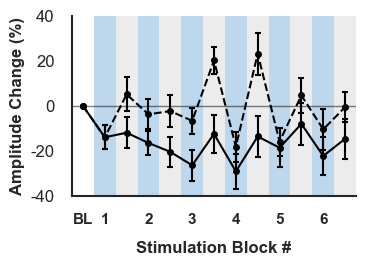

In [23]:


# --- עיבוד נתונים ---
data_list = for_avg_props_raw['relative_spike_amplitude']['all']
df_cum = get_clean_matrix(data_list, mode='baseline')   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive') # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#91bde1' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.6, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרת שנתות ציר Y כל 10%
y_ticks = np.arange(-40, 50, 20) # מ-40- עד 40 (כולל) בקפיצות של 10
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontsize=12) # הקטנת פונט מספרים בציר Y
ax.set_ylim(-40, 40)

# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)

# 5. מקרא (אופציונלי להחזיר אם תרצה)
stim_patch = mpatches.Patch(color='#8db4d3', label='Stimulation Block')
pause_patch = mpatches.Patch(color='#e0e0e0', label='Pause Block')

plt.savefig('amplitude_cumulative_vs_consecutive+groups.pdf', bbox_inches='tight') 
plt.tight_layout()
plt.show()

Plotting data for subject index: 4


C:\Users\user\AppData\Local\Temp\ipykernel_35144\1462585180.py:38: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--',


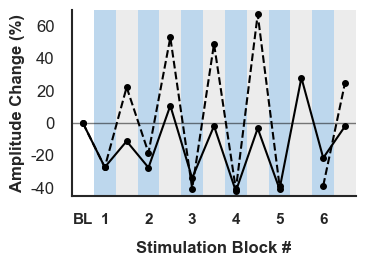

In [140]:
# --- עיבוד נתונים ---
data_list = for_avg_props_raw['relative_spike_amplitude']['all']
df_cum = get_clean_matrix(data_list, mode='baseline')   
df_imm = get_clean_matrix(data_list, mode='consecutive') 

# --- בחירת נבדק ספציפי ---
subject_index = 4  # שנה את המספר הזה כדי לבחור נבדק אחר (0 הוא הראשון)

# במקום mean ו-sem, אנחנו לוקחים שורה אחת בלבד
mean_cum = df_cum.iloc[subject_index]
mean_imm = df_imm.iloc[subject_index]

# מאחר ומדובר בנבדק אחד, אין "טעות תקן" (Error bars)
sem_cum = None
sem_imm = None

# בדיקה איזה נבדק אנחנו מציגים
print(f"Plotting data for subject index: {subject_index}")

x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני (נשאר זהה)
for j in range(1, len(mean_cum)):
    color = '#91bde1' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.6, linewidth=0)

# 2. הגדרות סטייל (נשאר זהה)
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים (yerr=None יבטל אוטומטית את קווי השגיאה)
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label=f'Subj {subject_index}: Cumulative', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label=f'Subj {subject_index}: Immediate', **err_style)

# 3. קו אפס ועיצוב צירים (נשאר זהה)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרות Ticks
y_ticks = np.arange(-40, 65, 20) 
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontsize=12) 
ax.set_ylim(-45, 70)

stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)

plt.tight_layout()
plt.savefig(rf'amplitude_489.pdf')
plt.show()

Data points per block (after outlier removal):
[13, 13, 13, 12, 13, 12, 12, 12, 12, 9, 9, 6, 6]


C:\Users\user\AppData\Local\Temp\ipykernel_35144\3190967632.py:63: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--',


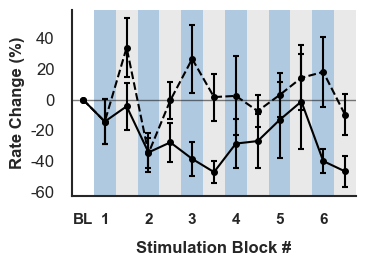

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

def get_clean_matrix(raw_data_list, mode='baseline', max_points=13, threshold=3):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

# --- עיבוד נתונים ---
data_list = for_avg_props_raw['rates']['all']
df_cum = get_clean_matrix(data_list, mode='baseline')   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive') # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#8db4d3' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.7, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרת שנתות ציר Y כל 10%
y_ticks = np.arange(-60, 50, 20) # מ-40- עד 40 (כולל) בקפיצות של 10
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontsize=12) # הקטנת פונט מספרים בציר Y
# ax.set_ylim(-45, 40)

# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)

# 5. מקרא (אופציונלי להחזיר אם תרצה)
stim_patch = mpatches.Patch(color='#8db4d3', label='Stimulation Block')
pause_patch = mpatches.Patch(color='#e0e0e0', label='Pause Block')

plt.savefig('rates_cumulative_vs_consecutive+groups.pdf', bbox_inches='tight') 
plt.tight_layout()
plt.show()

Change in Amplitude Between Consecutive Time Windows (%)
Inter-Window Amplitude Change (%)
Relative Amplitude Change (% from Previous Block)
Amplitude Modulation (% Change)
Amplitude Change Following State Transition (%)
Consecutive Block-to-Block Change (%)

Segment 2 (Start: 9444s) Peak Height: 737.41 µV
Segment 2 (Start: 9597s) Peak Height: 532.27 µV
Segment 2 (Start: 9661s) Peak Height: 288.06 µV


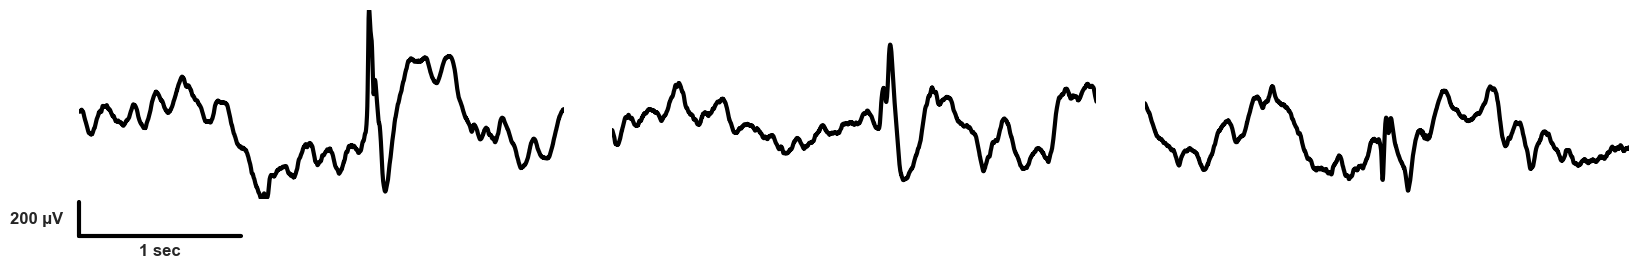

In [90]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# --------------------
# Parameters
# --------------------
edf_path = r"D:\Maya\p489\P489_fixed.edf"
channel_name = "LMH2"
duration = 3  
amp_bar_val = 200 # µV
time_bar_sec = 1 # שניה אחת

start_times = [                  
    2 * 3600 + 37 * 60 + 24, 
    2 * 3600 + 39 * 60 + 57,                 
    2 * 3600 + 41 * 60 + 1                  
]

# --------------------
# Load and Prepare Data
# --------------------
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
raw.pick([channel_name]) 

segments = []
for t_start in start_times:
    crop = raw.copy().crop(tmin=t_start, tmax=t_start + duration)
    data = crop.get_data()[0] * 1e6 
    segments.append(data)
    # הדפסת שיא הגובה עבור המקטע הנוכחי
    peak = np.max(data)
    print(f"Segment {i+1} (Start: {t_start}s) Peak Height: {peak:.2f} µV")

y_min_global = min([np.min(s) for s in segments])
y_max_global = max([np.max(s) for s in segments])

# --------------------
# Plot (Horizontal Layout)
# --------------------
# שינוי ל-1 row, 3 columns וגודל פיגר מתאים לרוחב
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 3), sharey=True)

for i, data in enumerate(segments):
    ax = axes[i]
    times = np.linspace(0, duration, len(data))
    # סיגנל עבה יותר (linewidth=1.2)
    ax.plot(times, data, color="black", linewidth=3) 
    
    ax.set_ylim(y_min_global, y_max_global)
    ax.set_xlim(0, duration)
    ax.set_axis_off()

# --------------------
# Scale Bar "L" Shape (Positioned under the first segment)
# --------------------
ax_ref = axes[0] 

# הגדלת הרווח מתחת לסיגנל
# נוריד את ה-corner_y עוד יותר מתחת ל-y_min_global
vertical_gap = abs(y_max_global - y_min_global) * 0.2 # 20% margin
corner_x = 0 
corner_y = y_min_global - vertical_gap

# 1. הבר האנכי (מתח)
ax_ref.plot([corner_x, corner_x], [corner_y, corner_y + amp_bar_val],
            color="black", linewidth=3, clip_on=False, zorder=5)

# 2. הבר האופקי (זמן)
ax_ref.plot([corner_x, corner_x + time_bar_sec], [corner_y, corner_y],
            color="black", linewidth=3, clip_on=False, zorder=5)

# 3. כיתובים
ax_ref.text(corner_x - 0.1, corner_y + (amp_bar_val / 2), f"{amp_bar_val} µV", 
            va="center", ha="right", fontsize=12, fontweight='bold')

ax_ref.text(corner_x + (time_bar_sec / 2), corner_y - (vertical_gap * 0.2), 
            f"{time_bar_sec} sec", va="top", ha="center", fontsize=12, fontweight='bold')

# התאמת שוליים כדי שה-scale bar לא ייחתך
plt.subplots_adjust(bottom=0.25, wspace=0.1) 

# שמירה ל-PDF (אופציונלי, כפי שביקשת קודם)
plt.savefig("raw_examples_489_LMH2.pdf", bbox_inches='tight')

plt.show()

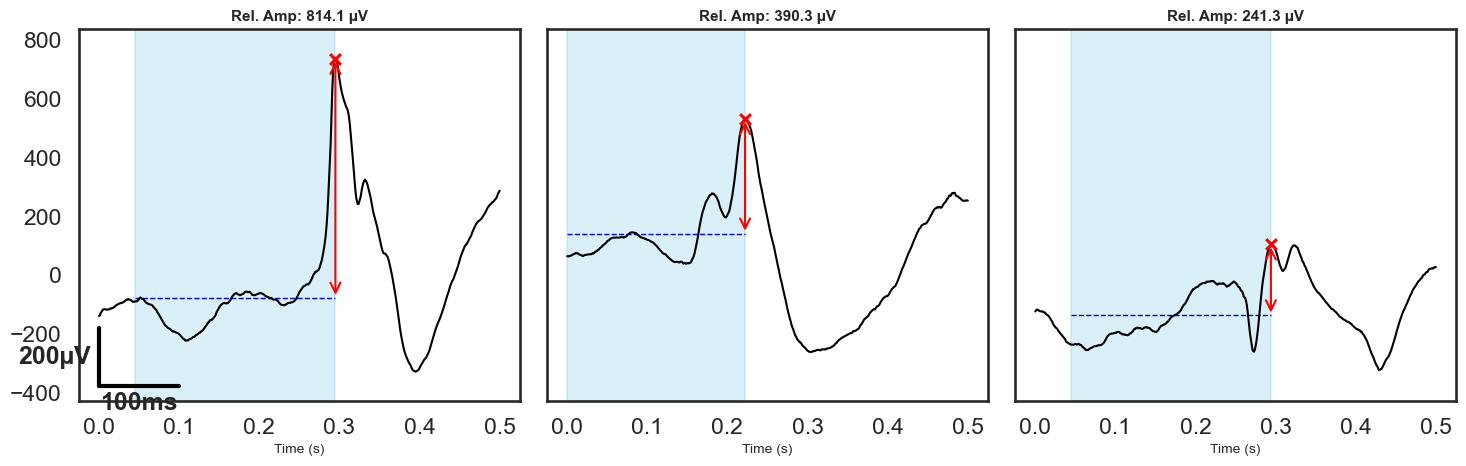

In [160]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# --------------------
# Parameters
# --------------------
edf_path = r"D:\Maya\p489\P489_fixed.edf"
channel_name = "LMH2"
duration = 0.5  
amp_bar_val = 200 
time_bar_sec = 0.1 
baseline_sec = 0.25 # 50ms

start_times = [                  
    2 * 3600 + 37 * 60 + 25.5, 
    2 * 3600 + 39 * 60 + 58.5,                 
    2 * 3600 + 41 * 60 + 2.2                  
]

# --------------------
# Load Data
# --------------------
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
sfreq = raw.info['sfreq']
raw.pick([channel_name]) 

segments = []
metrics = []

for t_start in start_times:
    crop = raw.copy().crop(tmin=t_start, tmax=t_start + duration)
    data = crop.get_data()[0] * 1e6 
    segments.append(data)
    
    # חישובים
    peak_idx = np.argmax(data)
    points_before = int(baseline_sec * sfreq)
    start_base_idx = max(0, peak_idx - points_before)
    
    avg_baseline = np.mean(data[start_base_idx:peak_idx])
    rel_amp = data[peak_idx] - avg_baseline
    
    # שמירת נתונים לציור
    metrics.append({
        'peak_idx': peak_idx,
        'start_base_idx': start_base_idx,
        'baseline_val': avg_baseline,
        'rel_amp': rel_amp
    })

# --------------------
# Plotting
# --------------------
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5), sharey=True)
times = np.linspace(0, duration, len(segments[0]))

for i, ax in enumerate(axes):
    data = segments[i]
    m = metrics[i]
    
    # 1. ציור הסיגנל
    ax.plot(times, data, color="black", linewidth=1.5, zorder=3)
    
    # 2. סימון ה-Baseline (תיבה כחולה שקופה)
    t_base_start = times[m['start_base_idx']]
    t_base_end = times[m['peak_idx']]
    ax.axvspan(t_base_start, t_base_end, color='skyblue', alpha=0.3, label='Baseline Window')
    
    # 3. סימון ה-Peak (איקס אדום)
    ax.scatter(times[m['peak_idx']], data[m['peak_idx']], color='red', marker='x', s=60, zorder=5, label='Peak')
    
    # 4. קו עזר לאמפליטודה היחסית
    # קו אופקי שמראה את גובה ה-baseline וקו אנכי שמראה את הקפיצה
    ax.hlines(y=m['baseline_val'], xmin=t_base_start, xmax=t_base_end, color='blue', linestyle='--', linewidth=1)
    ax.annotate('', xy=(times[m['peak_idx']], data[m['peak_idx']]), 
                xytext=(times[m['peak_idx']], m['baseline_val']),
                arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))

    # עיצוב
    ax.set_ylim(min([np.min(s) for s in segments]) - 100, max([np.max(s) for s in segments]) + 100)
    ax.set_title(f"Rel. Amp: {m['rel_amp']:.1f} µV", fontsize=11, fontweight='bold')
    ax.set_xlabel("Time (s)", fontsize=10)

# --------------------
# Scale Bar & Legend
# --------------------
ax_ref = axes[0]
corner_x, corner_y = 0, ax_ref.get_ylim()[0] + 50
ax_ref.plot([corner_x, corner_x], [corner_y, corner_y + amp_bar_val], color="black", linewidth=3)
ax_ref.plot([corner_x, corner_x + time_bar_sec], [corner_y, corner_y], color="black", linewidth=3)
ax_ref.text(corner_x - 0.01, corner_y + amp_bar_val/2, f"{amp_bar_val}µV", ha='right', va='center', fontweight='bold')
ax_ref.text(corner_x + time_bar_sec/2, corner_y - 20, f"{int(time_bar_sec*1000)}ms", ha='center', va='top', fontweight='bold')

plt.tight_layout()
plt.show()

Processing Subj 497...
Processing Subj 498...
Data is ready for plotting!


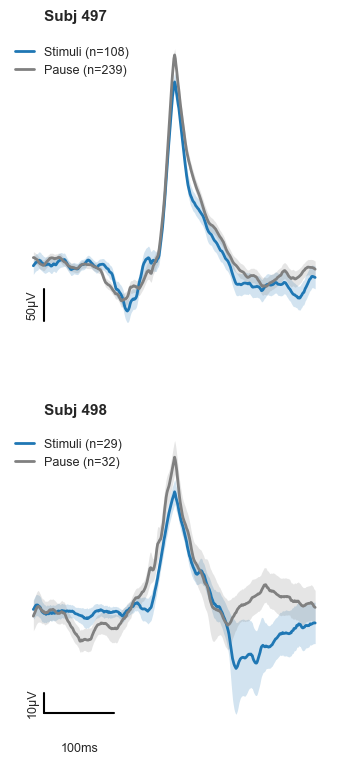

In [133]:
import os
import numpy as np
import pandas as pd
import mne
import utils

# הגדרות בסיס
base_path = r"D:\Ofer_backup\V6_model"
PRE_MS, POST_MS = 200, 200
cases = [
    {"subj": "497", "chan": "LEC1"},
    {"subj": "498", "chan": "RA1"}
]

all_results = {} # כאן יישמרו כל הנתונים המוכנים

for case in cases:
    subj_id, ch_name = case["subj"], case["chan"]
    print(f"Processing Subj {subj_id}...")
    
    # טעינת נתיבים
    edf_path = rf"D:\Maya\p{subj_id}\P{subj_id}_fixed.edf"
    features_csv = os.path.join(base_path, f"p{subj_id}", "unichannel_model", "min_amplitude_1", "features", f"p{subj_id}_flat_features.csv")
    clean_annot_path = rf"D:\Maya\clean Stim Project\P{subj_id}\P{subj_id}_annotations_ms.csv"

    # עיבוד DataFrame
    df = pd.read_csv(features_csv)
    # df = df[df["hypnogram_flag"] == "nrem"].copy()
    df = df.drop_duplicates(subset=["group"], keep="first")
    df = utils.remove_noisy_samples_and_channels(subj_id, df, clean_annot_path, ts_col="timestamp", channel_col="channel")
    df_target = df[(df["channel"] == ch_name) & (df["stimuli_flag"].isin(["stimuli_block", "pause_block"]))]

    # קריאת EDF
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
    fs = raw.info["sfreq"]
    w_len = int((PRE_MS + POST_MS) * fs / 1000)
    
    waveforms = {"stimuli_block": [], "pause_block": []}
    for _, row in df_target.iterrows():
        t_start = (row["timestamp"] - PRE_MS) / 1000
        t_stop = (row["timestamp"] + POST_MS) / 1000
        try:
            wf = raw.get_data(picks=[ch_name], tmin=t_start, tmax=t_stop, return_times=False)
            wf = np.squeeze(wf) * 1e6 # המרה ל-uV
            if len(wf) >= w_len:
                wf_final = wf[:w_len] - np.mean(wf[:int(PRE_MS * fs / 1000)])
                waveforms[row["stimuli_flag"]].append(wf_final)
        except: continue
        
    all_results[f"{subj_id}_{ch_name}"] = {"data": waveforms, "fs": fs}

print("Data is ready for plotting!")
# פרמטרים לציור
SCALE_X = 100        
COLORS = {"stimuli_block": "#1f77b4", "pause_block": "#808080"}
LEGEND_LABELS = {"stimuli_block": "Stimuli", "pause_block": "Pause"}

scale_y_values = [50, 10] 

fig, axes = plt.subplots(2, 1, figsize=(4, 9)) # הגבהתי מעט את הפיגורה ל-9

for i, (key, content) in enumerate(all_results.items()):
    waveforms = content["data"]
    fs = content["fs"]
    ax = axes[i]
    t = np.linspace(-PRE_MS, POST_MS, int((PRE_MS + POST_MS) * fs / 1000))
    current_scale_y = scale_y_values[i]
    
    for cond in ["stimuli_block", "pause_block"]:
        wf_list = waveforms[cond]
        if len(wf_list) > 0:
            W = np.vstack(wf_list)
            mean = np.mean(W, axis=0)
            sem = np.std(W, axis=0) / np.sqrt(W.shape[0])
            
            label_with_n = f"{LEGEND_LABELS[cond]} (n={len(wf_list)})"
            ax.plot(t, mean, color=COLORS[cond], lw=2, label=label_with_n)
            ax.fill_between(t, mean - sem, mean + sem, color=COLORS[cond], alpha=0.2, lw=0)

    ax.set_axis_off()
    
    # כותרת נבדק - הוספתי pad ויזואלי על ידי העלאת ה-y position
    # ושימוש ב-va='bottom' כדי שיהיה רווח מהסיגנל
    y_max_curr = ax.get_ylim()[1]
    ax.text(-185, y_max_curr * 1.05, f"Subj {key.split('_')[0]}", 
            fontsize=11, fontweight='bold', va='bottom')

    # מקרא - הוספת bbox_to_anchor עם קצת יותר רווח מלמעלה
    ax.legend(loc='upper left', frameon=False, fontsize=9, 
              bbox_to_anchor=(-0.05, 1.0), handlelength=1.5)

    # Scale Bar
    y_min_local, y_max_local = ax.get_ylim()
    y_range = y_max_local - y_min_local
    x_start, y_start = -185, y_min_local + (y_range * 0.05)
    
    ax.plot([x_start, x_start], [y_start, y_start + current_scale_y], color='black', lw=1.5)
    ax.text(x_start - 8, y_start + current_scale_y/2, f'{current_scale_y}µV', 
            ha='right', va='center', rotation=90, fontsize=9)
    
    if i == 1:
        ax.plot([x_start, x_start + SCALE_X], [y_start, y_start], color='black', lw=1.5)
        ax.text(x_start + SCALE_X/2, y_start - (y_range * 0.1), 
                f'{SCALE_X}ms', ha='center', va='top', fontsize=9)

# הגדלת המרווח בין הגרפים כדי למנוע צפיפות בין הכותרת של התחתון ל-Scale Bar של העליון
plt.subplots_adjust(hspace=0.3)
plt.savefig('amp_chan_avg_example.pdf', bbox_inches='tight')
plt.show()

In [83]:
import os
import numpy as np
import pandas as pd
import mne
import utils

# הגדרות בסיס
base_path = r"D:\Ofer_backup\V6_model"
PRE_MS, POST_MS = 200, 200
cases = [
    {"subj": "497", "chan": "LEC1"},
    {"subj": "497", "chan": "LA1"}
]

all_results = {} # כאן יישמרו כל הנתונים המוכנים

for case in cases:
    subj_id, ch_name = case["subj"], case["chan"]
    print(f"Processing Subj {subj_id}...")
    
    # טעינת נתיבים
    edf_path = rf"D:\Maya\p{subj_id}\P{subj_id}_fixed.edf"
    features_csv = os.path.join(base_path, f"p{subj_id}", "unichannel_model", "min_amplitude_1", "features", f"p{subj_id}_flat_features.csv")
    clean_annot_path = rf"D:\Maya\clean Stim Project\P{subj_id}\P{subj_id}_annotations_ms.csv"

    # עיבוד DataFrame
    df = pd.read_csv(features_csv)
    # df = df[df["hypnogram_flag"] == "nrem"].copy()
    df = df.drop_duplicates(subset=["group"], keep="first")
    df = utils.remove_noisy_samples_and_channels(subj_id, df, clean_annot_path, ts_col="timestamp", channel_col="channel")
    df_target = df[(df["channel"] == ch_name) & (df["stimuli_flag"].isin(["stimuli_block", "pause_block"]))]

    # קריאת EDF
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
    fs = raw.info["sfreq"]
    w_len = int((PRE_MS + POST_MS) * fs / 1000)
    
    waveforms = {"stimuli_block": [], "pause_block": []}
    for _, row in df_target.iterrows():
        t_start = (row["timestamp"] - PRE_MS) / 1000
        t_stop = (row["timestamp"] + POST_MS) / 1000
        try:
            wf = raw.get_data(picks=[ch_name], tmin=t_start, tmax=t_stop, return_times=False)
            wf = np.squeeze(wf) * 1e6 # המרה ל-uV
            if len(wf) >= w_len:
                wf_final = wf[:w_len] - np.mean(wf[:int(PRE_MS * fs / 1000)])
                waveforms[row["stimuli_flag"]].append(wf_final)
        except: continue
        
    all_results[f"{subj_id}_{ch_name}"] = {"data": waveforms, "fs": fs}

print("Data is ready for plotting!")

Processing Subj 497...
Processing Subj 497...
Data is ready for plotting!


Case 497_LEC1: Stim Peak=281.90uV, Pause Peak=331.07uV. Difference: 14.9%
Case 497_LA1: Stim Peak=237.73uV, Pause Peak=268.19uV. Difference: 11.4%


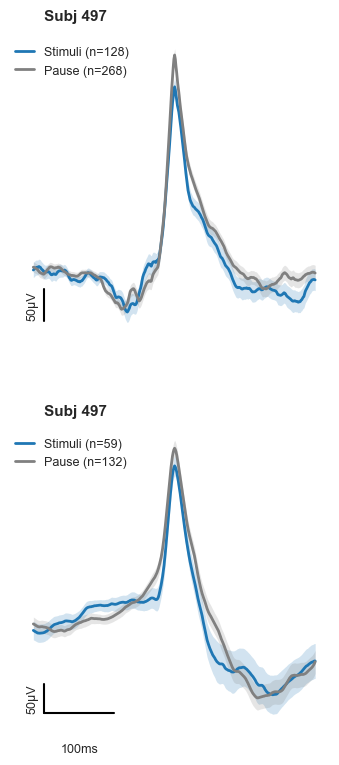

In [87]:
# פרמטרים לציור
SCALE_X = 100        
COLORS = {"stimuli_block": "#1f77b4", "pause_block": "#808080"}
LEGEND_LABELS = {"stimuli_block": "Stimuli", "pause_block": "Pause"}

scale_y_values = [50, 50] 

fig, axes = plt.subplots(2, 1, figsize=(4, 9)) # הגבהתי מעט את הפיגורה ל-9

for i, (key, content) in enumerate(all_results.items()):
    waveforms = content["data"]
    fs = content["fs"]
    ax = axes[i]
    t = np.linspace(-PRE_MS, POST_MS, int((PRE_MS + POST_MS) * fs / 1000))
    current_scale_y = scale_y_values[i]
    
    max_peaks = {} # לאחסון שיאי הגובה
    
    for cond in ["stimuli_block", "pause_block"]:
        wf_list = waveforms[cond]
        if len(wf_list) > 0:
            W = np.vstack(wf_list)
            mean = np.mean(W, axis=0)
            sem = np.std(W, axis=0) / np.sqrt(W.shape[0])
            
            # שמירת שיא הגובה (אבסולוטי) של הממוצע
            max_peaks[cond] = np.max(np.abs(mean))
            
            label_with_n = f"{LEGEND_LABELS[cond]} (n={len(wf_list)})"
            ax.plot(t, mean, color=COLORS[cond], lw=2, label=label_with_n)
            ax.fill_between(t, mean - sem, mean + sem, color=COLORS[cond], alpha=0.2, lw=0)

    # --- חישוב הפרש בשיא הגובה (Peak Amplitude) ---
    if "stimuli_block" in max_peaks and "pause_block" in max_peaks:
        p1, p2 = max_peaks["stimuli_block"], max_peaks["pause_block"]
        pct_diff = abs(p1 - p2) / p2 * 100
        print(f"Case {key}: Stim Peak={p1:.2f}uV, Pause Peak={p2:.2f}uV. Difference: {pct_diff:.1f}%")

    ax.set_axis_off()
    
    # כותרת נבדק - הוספתי pad ויזואלי על ידי העלאת ה-y position
    # ושימוש ב-va='bottom' כדי שיהיה רווח מהסיגנל
    y_max_curr = ax.get_ylim()[1]
    ax.text(-185, y_max_curr * 1.05, f"Subj {key.split('_')[0]}", 
            fontsize=11, fontweight='bold', va='bottom')

    # מקרא - הוספת bbox_to_anchor עם קצת יותר רווח מלמעלה
    ax.legend(loc='upper left', frameon=False, fontsize=9, 
              bbox_to_anchor=(-0.05, 1.0), handlelength=1.5)

    # Scale Bar
    y_min_local, y_max_local = ax.get_ylim()
    y_range = y_max_local - y_min_local
    x_start, y_start = -185, y_min_local + (y_range * 0.05)
    
    ax.plot([x_start, x_start], [y_start, y_start + current_scale_y], color='black', lw=1.5)
    ax.text(x_start - 8, y_start + current_scale_y/2, f'{current_scale_y}µV', 
            ha='right', va='center', rotation=90, fontsize=9)
    
    if i == 1:
        ax.plot([x_start, x_start + SCALE_X], [y_start, y_start], color='black', lw=1.5)
        ax.text(x_start + SCALE_X/2, y_start - (y_range * 0.1), 
                f'{SCALE_X}ms', ha='center', va='top', fontsize=9)

# הגדלת המרווח בין הגרפים כדי למנוע צפיפות בין הכותרת של התחתון ל-Scale Bar של העליון
plt.subplots_adjust(hspace=0.3)
plt.savefig('amp_chan_avg_example_no_stages_497_LEC_LA.pdf', bbox_inches='tight')
plt.show()

# Rates

In [28]:
import joblib
data_stim = joblib.load(r"C:\repos\spikes_stim\paper\for_avg_props_raw_stim.pkl")
data_control = joblib.load(r"C:\repos\spikes_stim\paper\for_avg_props_raw_controls.pkl")

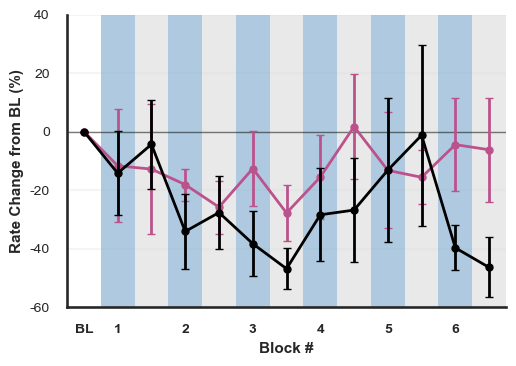

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- עיבוד נתונים (בהנחה שהפונקציה get_clean_matrix הוגדרה קודם) ---
df_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
df_control = get_clean_matrix(data_control['rates']['all'], mode='baseline')

mean_stim = df_stim.mean()
sem_stim = df_stim.sem()
mean_ctrl = df_control.mean()
sem_ctrl = df_control.sem()

x_indices = np.arange(len(mean_stim))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(5.5, 4)) # הגדלתי מעט את הרוחב למקרא

# 1. רקע צבעוני לבלוקים
for j in range(1, len(mean_stim)):
    color = '#8db4d3' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.7, linewidth=0)

# 2. ציור הקווים
# קבוצת הניסוי - כחול עמוק
ax.errorbar(x_indices, mean_stim, yerr=sem_stim, fmt='-o', color='black', 
            capsize=3, markersize=5, linewidth=2, label='Stimulation Group', zorder=5)

# קבוצת הביקורת - ורוד ce84ad
ax.errorbar(x_indices, mean_ctrl, yerr=sem_ctrl, fmt='-o', color='#bb528c', 
            capsize=3, markersize=5, linewidth=2, label='Control Group', zorder=4)

# 3. עיצוב ציר Y
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)
# הגדרה הגיונית לציר Y בהתאם לדאטה (מ-80- עד 60+)
ax.set_ylim(-60, 40)
y_ticks = np.arange(-60, 41, 20)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontsize=10)
ax.set_ylabel('Rate Change from BL (%)', fontsize=11, fontweight='bold')

# 4. עיצוב ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_stim), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_stim), 2)])
ax.set_xticklabels(stim_labels, fontsize=10, fontweight='bold')
ax.set_xlabel('Block #', fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, len(mean_stim) - 0.5)

# 5. ניקוי מסגרת
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)

# 6. מקרא - שמאל למעלה
# ax.legend(frameon=True, fontsize=9, loc='upper left', facecolor='white', framealpha=0.8)
plt.savefig('rates_controls_vs_stim.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()


--- Statistical Results ---

Phase: ON
  Stim vs 0: p = 0.01990
  Ctrl vs 0: p = 0.19141
  Stim vs Ctrl: p = 0.08070

Phase: OFF
  Stim vs 0: p = 0.04712
  Ctrl vs 0: p = 0.09766
  Stim vs Ctrl: p = 0.18688


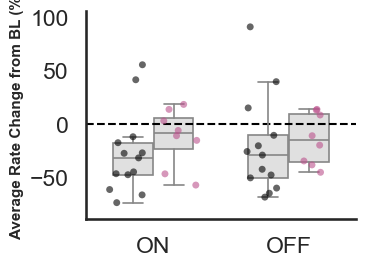

In [33]:

def plot_split_groups_reproducible_safe(data_stim, data_control):
    # 1. ניקוי וסגירת פיגרים קודמים
    plt.close('all')
    fig, ax = plt.subplots(figsize=(4, 3))
    
    # 2. עיבוד נתונים
    df_s = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
    df_c = get_clean_matrix(data_control['rates']['all'], mode='baseline')
    
    def get_split_means(df, group_name):
        stim_blocks = df.iloc[:, 1::2].mean(axis=1)
        pause_blocks = df.iloc[:, 2::2].mean(axis=1)
        return pd.DataFrame({
            'Change': pd.concat([stim_blocks, pause_blocks]),
            'Block_Type': ['ON']*len(stim_blocks) + ['OFF']*len(pause_blocks),
            'Group': group_name
        }).dropna()

    plot_df = pd.concat([get_split_means(df_s, 'Stimulation'), get_split_means(df_c, 'Control')])
    
    group_order = ['Stimulation', 'Control']
    point_pal = {'Stimulation': 'black', 'Control': '#bb528c'}
    box_color = '#e0e0e0'
    
    # 3. יצירת בוקספלוט
    sns.set_style("white")
    sns.boxplot(data=plot_df, x='Block_Type', y='Change', hue='Group', 
                hue_order=group_order, color=box_color, width=0.6, 
                fliersize=0, zorder=2, linewidth=1.2, ax=ax)
    
    for patch in ax.patches:
        patch.set_facecolor(box_color)

    # 4. פריסת נקודות קבועה - הדרך הבטוחה
    # הגדרת ה-Seed כאן מבטיחה שה-Jitter של stripplot יהיה זהה בכל הרצה
    np.random.seed(4) 
    
    sns.stripplot(data=plot_df, x='Block_Type', y='Change', hue='Group', 
                  hue_order=group_order, dodge=True, palette=point_pal, 
                  alpha=0.6, size=5, jitter=0.25, ax=ax, zorder=3)

    # 5. הדפסת סטטיסטיקה מלאה
    print("\n--- Statistical Results ---")
    for b_type in ['ON', 'OFF']:
        s_vals = plot_df[(plot_df['Block_Type'] == b_type) & (plot_df['Group'] == 'Stimulation')]['Change']
        c_vals = plot_df[(plot_df['Block_Type'] == b_type) & (plot_df['Group'] == 'Control')]['Change']
        print(f"\nPhase: {b_type}")
        if len(s_vals) >= 5:
            res_w = wilcoxon(s_vals, alternative='less')
            print(f"  Stim vs 0: p = {res_w.pvalue:.5f}")
        if len(c_vals) >= 5:
            res_w = wilcoxon(c_vals, alternative='less')
            print(f"  Ctrl vs 0: p = {res_w.pvalue:.5f}")
        if len(s_vals) >= 5 and len(c_vals) >= 5:
            _, p_mw = mannwhitneyu(s_vals, c_vals, alternative='less')
            print(f"  Stim vs Ctrl: p = {p_mw:.5f}")

    # 6. עיצוב סופי
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)
    ax.set_ylabel('Average Rate Change from BL (%)', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    if ax.get_legend(): ax.get_legend().remove()
    ax.set_ylim(plot_df['Change'].min() - 15, plot_df['Change'].max() + 15)
    
    sns.despine()
    plt.tight_layout()
    # plt.savefig('rates_avg_per_patient.pdf', bbox_inches='tight')
    plt.show()

# הרצה
plot_split_groups_reproducible_safe(data_stim, data_control)


   TOTAL AVERAGE PER SUBJECT STATISTICS
Stimulation vs 0 (Wilcoxon) | p = 0.03406
Control     vs 0 (Wilcoxon) | p = 0.15625
Stim vs Control (Mann-Wh)   | p = 0.15056


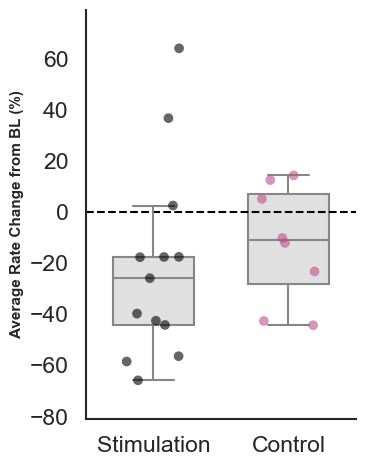

In [34]:

def plot_total_avg_per_subject(data_stim, data_control):
    # 1. ניקוי וסגירת פיגרים קודמים
    plt.close('all')
    fig, ax = plt.subplots(figsize=(4, 5))
    temporal_stim = ['489', '496', '538']
    
    # 2. עיבוד נתונים - ממוצע של כל נבדק על פני כל הבלוקים
    df_s_raw = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
    df_c_raw = get_clean_matrix(data_control['rates']['all'], mode='baseline')
    
    def get_total_means(df, group_name):
        # חישוב ממוצע לכל שורה (נבדק) לאורך כל העמודות (בלוקים)
        total_means = df.mean(axis=1)
        return pd.DataFrame({
            'Change': total_means,
            'Group': group_name,
            'Subject': [str(s) for s in df.index]
        }).dropna()

    plot_df = pd.concat([get_total_means(df_s_raw, 'Stimulation'), 
                         get_total_means(df_c_raw, 'Control')])
    
    # הוספת סימון לנבדקי Temporal
    plot_df['is_temporal'] = plot_df['Subject'].isin(temporal_stim) & (plot_df['Group'] == 'Stimulation')
    
    group_order = ['Stimulation', 'Control']
    point_pal = {'Stimulation': 'black', 'Control': '#bb528c'}
    box_color = '#e0e0e0'
    
    # 3. יצירת בוקספלוט
    sns.set_style("white")
    sns.boxplot(data=plot_df, x='Group', y='Change', order=group_order,
                color=box_color, width=0.6, fliersize=0, zorder=2, linewidth=1.5, ax=ax)
    
    for patch in ax.patches:
        patch.set_facecolor(box_color)

    # 4. פריסת נקודות קבועה
    np.random.seed(4) 
    # ציור נקודות רגילות
    sns.stripplot(data=plot_df[~plot_df['is_temporal']], x='Group', y='Change', 
                  order=group_order, palette=point_pal, alpha=0.6, size=7, 
                  jitter=0.2, ax=ax, zorder=3)

    # הדגשת נבדקי Temporal ב-X אדום
    np.random.seed(4) # שימוש באותו סיד לסנכרון הג'יטר
    temp_df = plot_df[plot_df['is_temporal']]
    if not temp_df.empty:
        sns.stripplot(data=temp_df, x='Group', y='Change', order=group_order,
                      color='red', marker='X', size=10, jitter=0.2, 
                      ax=ax, zorder=4, linewidth=1, edgecolor='black')

    # 5. הדפסת סטטיסטיקה מלאה (חד-כיוונית)
    print("\n" + "="*45)
    print("   TOTAL AVERAGE PER SUBJECT STATISTICS")
    print("="*45)
    
    s_vals = plot_df[plot_df['Group'] == 'Stimulation']['Change']
    c_vals = plot_df[plot_df['Group'] == 'Control']['Change']
    
    # מול אפס
    _, p_s0 = wilcoxon(s_vals, alternative='less')
    _, p_c0 = wilcoxon(c_vals, alternative='less')
    # בין קבוצות
    _, p_mw = mannwhitneyu(s_vals, c_vals, alternative='less')
    
    print(f"Stimulation vs 0 (Wilcoxon) | p = {p_s0:.5f}")
    print(f"Control     vs 0 (Wilcoxon) | p = {p_c0:.5f}")
    print(f"Stim vs Control (Mann-Wh)   | p = {p_mw:.5f}")

    # 6. עיצוב סופי
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)
    ax.set_ylabel('Average Rate Change from BL (%)', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    
    # עיבוי צירים לאחידות
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(1.5)
    ax.tick_params(width=1.5)
    
    if ax.get_legend(): ax.get_legend().remove()
    ax.set_ylim(plot_df['Change'].min() - 15, plot_df['Change'].max() + 15)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_total_avg_per_subject(data_stim, data_control)

Successfully highlighted subjects: ['489' '496' '538']


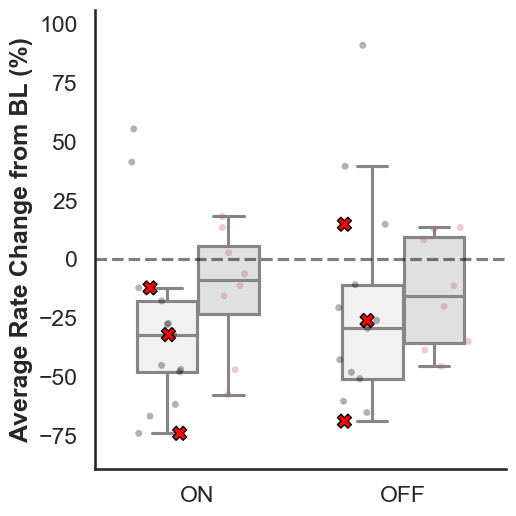

In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, wilcoxon

def plot_with_fixed_subject_names(data_stim, data_control):
    plt.close('all')
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    
    # 1. שחזור רשימת הנבדקים המקורית
    # curr_run_subjects מוגדר בקוד שלך, נוריד את 515 ו-545
    original_subjects = [x for x in curr_run_subjects if x not in ['515', '545']]
    temporal_stim = ['489', '496', '538']
    group_order = ['Stimulation', 'Control']
    
    # 2. עיבוד נתונים
    df_s = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
    df_c = get_clean_matrix(data_control['rates']['all'], mode='baseline')
    
    def get_split_means(df, group_name, subj_list=None):
        stim_blocks = df.iloc[:, 1::2].mean(axis=1)
        pause_blocks = df.iloc[:, 2::2].mean(axis=1)
        
        if subj_list is not None and len(df) == len(subj_list):
            actual_subjects = subj_list
        else:
            actual_subjects = [str(i) for i in df.index]
            
        return pd.DataFrame({
            'Change': pd.concat([stim_blocks, pause_blocks]),
            'Block_Type': ['ON']*len(stim_blocks) + ['OFF']*len(pause_blocks),
            'Group': group_name,
            'Subject': actual_subjects * 2
        }).dropna()

    plot_df_s = get_split_means(df_s, 'Stimulation', subj_list=original_subjects)
    plot_df_c = get_split_means(df_c, 'Control')
    plot_df = pd.concat([plot_df_s, plot_df_c])

    # 3. הגדרות תצוגה
    sns.set_style("white")
    sns.boxplot(data=plot_df, x='Block_Type', y='Change', hue='Group', 
                hue_order=group_order, color='#e0e0e0', width=0.6, 
                fliersize=0, zorder=2, ax=ax)

    # 4. ציור הנקודות הכלליות
    np.random.seed(42)
    sns.stripplot(data=plot_df, x='Block_Type', y='Change', hue='Group', 
                  hue_order=group_order, dodge=True, 
                  palette={'Stimulation': 'black', 'Control': '#bb528c'},
                  alpha=0.3, size=5, jitter=0.25, ax=ax, zorder=3)

    # 5. זיהוי וסימון נבדקי ה-Temporal
    highlight_df = plot_df[plot_df['Subject'].isin(temporal_stim) & (plot_df['Group'] == 'Stimulation')]
    
    if not highlight_df.empty:
        # פתרון ה-KeyError: הוספת 'Control' למילון הצבעים או הסרת hue_order
        np.random.seed(42)
        sns.stripplot(data=highlight_df, x='Block_Type', y='Change', hue='Group', 
                      hue_order=group_order, dodge=True, 
                      palette={'Stimulation': 'red', 'Control': 'none'}, # הוספת מפתח Control
                      size=10, jitter=0.25, ax=ax, zorder=5, marker='X', 
                      linewidth=1, edgecolor='black')
        print(f"Successfully highlighted subjects: {highlight_df['Subject'].unique()}")

    # 6. עיצוב וסטטיסטיקה
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_ylabel('Average Rate Change from BL (%)', fontweight='bold')
    ax.set_xlabel('')
    if ax.get_legend(): ax.get_legend().remove()
    ax.set_ylim(plot_df['Change'].min() - 15, plot_df['Change'].max() + 15)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_with_fixed_subject_names(data_stim, data_control)


   NON-PARAMETRIC ONE-TAILED RESULTS
Stimulation vs 0 (Wilcoxon) | p (one-tailed) = 0.03125
Pause vs 0       (Wilcoxon) | p (one-tailed) = 0.15625
Stim < Pause     (Wilcoxon) | p (one-tailed) = 0.28125


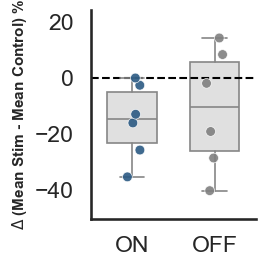

In [228]:
import seaborn as sns
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. חישוב הממוצעים וההפרשים (ממוצע קבוצתי לכל נקודת זמן)
mean_series_stim = df_stim.iloc[:, 1:].mean()
mean_series_ctrl = df_control.iloc[:, 1:].mean()
time_point_diffs = mean_series_stim - mean_series_ctrl

# 2. פיצול ל-6 נקודות גירוי (ON) ו-6 נקודות הפסקה (OFF)
stim_diffs = time_point_diffs.iloc[::2]
pause_diffs = time_point_diffs.iloc[1::2]

# 3. ניתוח סטטיסטי לא-פרמטרי חד-כיווני (One-tailed) - הדפסה בלבד
print("\n" + "="*45)
print("   NON-PARAMETRIC ONE-TAILED RESULTS")
print("="*45)

# א. האם הגירוי מוריד את ה-Rate מול 0? (Wilcoxon)
# alternative='less' בודק אם הערכים קטנים מ-0
_, p_stim_0_one = stats.wilcoxon(stim_diffs, alternative='less')

# ב. האם ההפסקה מראה ירידה מובהקת מול 0? (Wilcoxon)
_, p_pause_0_one = stats.wilcoxon(pause_diffs, alternative='less')

# ג. האם האפקט בגירוי חזק (נמוך) יותר מההפסקה? (Wilcoxon Paired)
# משתמשים ב-wilcoxon כי הנקודות מזווגות כרונולוגית
res_comp_one = stats.wilcoxon(stim_diffs, pause_diffs, alternative='less')

print(f"Stimulation vs 0 (Wilcoxon) | p (one-tailed) = {p_stim_0_one:.5f}")
print(f"Pause vs 0       (Wilcoxon) | p (one-tailed) = {p_pause_0_one:.5f}")
print(f"Stim < Pause     (Wilcoxon) | p (one-tailed) = {res_comp_one.pvalue:.5f}")

# 4. הכנת נתונים לגרף
plot_df = pd.DataFrame({
    'Difference': np.concatenate([stim_diffs.values, pause_diffs.values]),
    'Type': ['ON'] * 6 + ['OFF'] * 6
})

# 5. ויזואליזציה מעוצבת
plt.close('all')
fig, ax = plt.subplots(figsize=(3, 3))
sns.set_style("white")

group_order = ['ON', 'OFF']
point_pal = {'ON': '#2b5a83', 'OFF': '#808080'} 
box_color = '#e0e0e0' 

# בוקספלוט ניטרלי
sns.boxplot(data=plot_df, x='Type', y='Difference', order=group_order,
            color=box_color, width=0.6, fliersize=0, zorder=2, linewidth=1.2, ax=ax)

# צביעת הבוקסים באפור
for patch in ax.patches:
    patch.set_facecolor(box_color)

# הוספת נקודות (Jitter קטן למרכוז כמו במקור) עם Seed קבוע
np.random.seed(4) 
sns.stripplot(data=plot_df, x='Type', y='Difference', order=group_order,
              dodge=True, palette=point_pal, alpha=0.9, size=7, 
              jitter=0.1, edgecolor='white', linewidth=0.5, ax=ax, zorder=3)

# 6. עיצוב סופי
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)
ax.set_ylabel(r'$\Delta$ (Mean Stim - Mean Control) %', fontweight='bold', fontsize=11)
ax.set_xlabel('')

if ax.get_legend(): ax.get_legend().remove()
ax.set_ylim(plot_df['Difference'].min() - 10, plot_df['Difference'].max() + 10)

sns.despine()
plt.tight_layout()
plt.savefig('rates_diff_vs_control_boxplot.pdf', bbox_inches='tight')
plt.show()


   OVERALL EFFECT: ONE-TAILED WILCOXON
Overall Difference vs 0 | p (one-tailed) = 0.01343
ON vs OFF Comparison    | p (one-tailed) = 0.28125


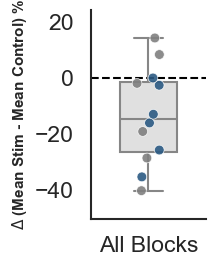

In [236]:
import seaborn as sns
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. חישוב הממוצעים וההפרשים - העתקה מדויקת של הלוגיקה שעבדה לך
mean_series_stim = df_stim.iloc[:, 1:].mean()
mean_series_ctrl = df_control.iloc[:, 1:].mean()
time_point_diffs = mean_series_stim - mean_series_ctrl

# פיצול ל-6 נקודות גירוי (ON) ו-6 נקודות הפסקה (OFF)
stim_diffs = time_point_diffs.iloc[::2]
pause_diffs = time_point_diffs.iloc[1::2]

# 2. ניתוח סטטיסטי לא-פרמטרי חד-כיווני (One-tailed Wilcoxon)
print("\n" + "="*45)
print("   OVERALL EFFECT: ONE-TAILED WILCOXON")
print("="*45)

# א. האם כל 12 הבלוקים יחד נמוכים מ-0 באופן מובהק?
_, p_overall = stats.wilcoxon(time_point_diffs, alternative='less')

# ב. האם הגירוי (ON) נמוך משמעותית מההפסקה (OFF)? (מבחן מזווג)
_, p_on_off = stats.wilcoxon(stim_diffs, pause_diffs, alternative='less')

print(f"Overall Difference vs 0 | p (one-tailed) = {p_overall:.5f}")
print(f"ON vs OFF Comparison    | p (one-tailed) = {p_on_off:.5f}")

# 3. הכנת נתונים לגרף - שימוש ב-concatenate מבטיח עקביות צבעים
# אנחנו יוצרים רשימה של 6 'ON' ואז 6 'OFF' שמתאימה בדיוק לסדר הערכים
plot_df = pd.DataFrame({
    'Difference': np.concatenate([stim_diffs.values, pause_diffs.values]),
    'Type': ['ON'] * 6 + ['OFF'] * 6,
    'Group': 'All Blocks' # שם קטגוריה אחת לציר ה-X
})

# 4. ויזואליזציה מעוצבת ואחידה
plt.close('all')
fig, ax = plt.subplots(figsize=(2.5, 3)) # פרופורציה צרה וגבוהה
sns.set_style("white")

point_pal = {'ON': '#2b5a83', 'OFF': '#808080'} # כחול ואפור המקוריים
box_color = '#e0e0e0' 

# בוקספלוט יחיד
sns.boxplot(data=plot_df, x='Group', y='Difference', color=box_color, 
            width=0.5, fliersize=0, zorder=2, linewidth=1.5, ax=ax)

# צביעת הבוקס
for patch in ax.patches:
    patch.set_facecolor(box_color)

# הוספת הנקודות - dodge=False גורם לכולן להיות על אותו ציר מרכזי
np.random.seed(4) 
sns.stripplot(data=plot_df, x='Group', y='Difference', hue='Type', 
              hue_order=['ON', 'OFF'], dodge=False, 
              palette=point_pal, alpha=0.9, size=7, jitter=0.1, 
              edgecolor='white', linewidth=0.5, ax=ax, zorder=3)

# 5. עיצוב סופי (עובי צירים 1.5 לאחידות)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)
ax.set_ylabel(r'$\Delta$ (Mean Stim - Mean Control) %', fontweight='bold', fontsize=11)
ax.set_xlabel('')

# עיבוי צירים (Spines)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.5)
ax.tick_params(width=1.5)

# הסרת המקרא
if ax.get_legend():
    ax.get_legend().remove()

# הגדרת גבולות ציר Y (מרווח סביר סביב הנתונים)
ax.set_ylim(plot_df['Difference'].min() - 10, plot_df['Difference'].max() + 10)

sns.despine()
plt.tight_layout()
plt.savefig('rates_diff_vs_control_united_boxplot.pdf', bbox_inches='tight')
plt.show()

Processing p485 for electrode RPSMA4...
Found 68 electrodes for p485. Looking for RPSMA4...
Processing p486 for electrode LOF4...
Found 89 electrodes for p486. Looking for LOF4...
Processing p487 for electrode ROF5...
Found 71 electrodes for p487. Looking for ROF5...
Processing p488 for electrode LOF4...
Found 87 electrodes for p488. Looking for LOF4...
Processing p489 for electrode RPHG5...
Found 82 electrodes for p489. Looking for RPHG5...
Processing p496 for electrode RTOP6...
Found 66 electrodes for p496. Looking for RTOP6...
Processing p497 for electrode ROF7...
Found 77 electrodes for p497. Looking for ROF7...
Processing p498 for electrode LOF6...
Found 76 electrodes for p498. Looking for LOF6...
Processing p499 for electrode LOF6...
Found 66 electrodes for p499. Looking for LOF6...
Processing p505 for electrode LOF-AC7...
Found 75 electrodes for p505. Looking for LOF-AC7...
Processing p510 for electrode ROF6...
Found 96 electrodes for p510. Looking for ROF6...
Processing p515 fo

AttributeError: 'GlassBrainAxes' object has no attribute 'cmap'

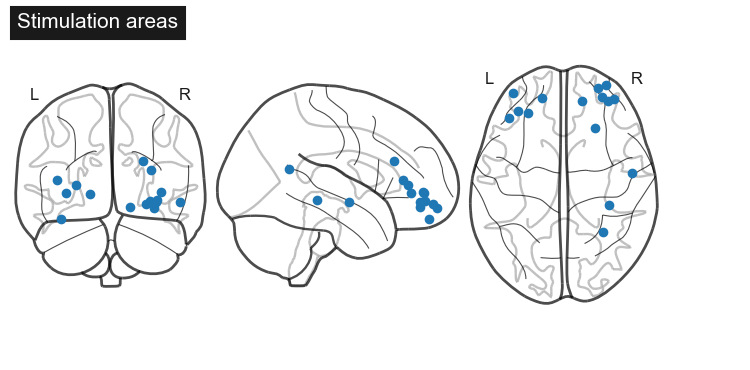

In [42]:
import pandas as pd
import numpy as np
from nilearn import plotting
import matplotlib.pyplot as plt

# --- שלב 1: הגדרת הפונקציות לקריאת וחישוב קואורדינטות ---

def read_coordinates_files(electrodes_name_file_path: str, electrodes_location_file_path: str):
    name_data = pd.read_csv(
        filepath_or_buffer=electrodes_name_file_path,
        delimiter=' ',
        usecols=[0],
        skiprows=2,
        header=None,
        dtype={0: str}
    )
    location_data = pd.read_csv(
        filepath_or_buffer=electrodes_location_file_path,
        delimiter=' ',
        skiprows=2,
        header=None,
        dtype={0: float, 1: float, 2: float}
    )

    name_to_coordinates = {}
    for names_row, location_row in zip(name_data.iterrows(), location_data.iterrows()):
        electrode_name = f'{names_row[1][0]}'
        name_to_coordinates[electrode_name] = (
            location_row[1][0],
            location_row[1][1],
            location_row[1][2]
        )
    return name_to_coordinates

def calculate_coordinates(avarage=True):
    # כאן הגדרתי גרסה פשוטה של הפונקציה שסורקת את התיקייה הכללית
    # הנתיב נלקח מהלוגיקה של הקוד הקודם שלך
    coordinates_dir = r'C:\repos\NirsLabProject\NirsLabProject\data\cordinates'
    
    _sum = {}
    count = {}
    
    # חיפוש קבצי שמות אלקטרודות
    files = [f for f in os.listdir(coordinates_dir) if f.endswith('.electrodeNames')]
    
    for file in files:
        loc_file_path = os.path.join(coordinates_dir, file)
        pial_file_path = os.path.join(coordinates_dir, file.replace('.electrodeNames', '.Pial'))
        
        if not os.path.exists(loc_file_path) or not os.path.exists(pial_file_path):
            continue
            
        electrode_name_to_location = read_coordinates_files(loc_file_path, pial_file_path)
        for electrode_name, location in electrode_name_to_location.items():
            if electrode_name not in _sum:
                _sum[electrode_name] = [0, 0, 0]
                count[electrode_name] = 0
            count[electrode_name] += 1
            _sum[electrode_name][0] += location[0]
            _sum[electrode_name][1] += location[1]
            _sum[electrode_name][2] += location[2]

    for electrode in _sum:
        _sum[electrode][0] /= count[electrode]
        _sum[electrode][1] /= count[electrode]
        _sum[electrode][2] /= count[electrode]

    return _sum

# --- שלב 2: הרצת התהליך על הנבדקים שלך ---

subjects = ['p485', 'p486', 'p487', 'p488', 'p489', 'p496', 'p497', 'p498', 'p499', 'p505', 'p5107', 'p515', 'p520', 'p538', 'p545']
all_coords = calculate_coordinates(avarage=True)

# 1. הגדרת המילון - התאימי את שמות האלקטרודות לפי מה שמופיע אצלך בנתונים
subject_to_electrode = {
    'p485': 'RPSMA4',
    'p486': 'LOF4',
    'p487': 'ROF5',
    'p488': 'LOF4',
    'p489': 'RPHG5',
    'p496': 'RTOP6',
    'p497': 'ROF7',
    'p498': 'LOF6',
    'p499': 'LOF6',
    'p505': 'LOF-AC7',
    'p510': 'ROF6',
    'p515': 'ROF2',
    'p520': 'ROF5',
    'p538': 'RHSG4',
    'p545': 'ROF4'
}

# 2. פונקציה לשליפת המיקומים הספציפיים בלבד
def get_selected_electrodes_data(subject_map):
    coordinates_dir = r'C:\repos\NirsLabProject\NirsLabProject\data\cordinates'
    selected_data = []
    
    for subj, target_electrode in subject_map.items():
        loc_file = os.path.join(coordinates_dir, f'{subj[1:]}.electrodeNames')
        print(f"Processing {subj} for electrode {target_electrode}...")
        pial_file = os.path.join(coordinates_dir, f'{subj[1:]}.PIAL')
        
        if os.path.exists(loc_file):
            # טעינת כל האלקטרודות של הנבדק
            subj_coords = read_coordinates_files(loc_file, pial_file)
            print(f"Found {len(subj_coords)} electrodes for {subj}. Looking for {target_electrode}...")
            
            # בדיקה אם האלקטרודה המבוקשת קיימת עבורו
            if target_electrode in subj_coords:
                x, y, z = subj_coords[target_electrode]
                selected_data.append({
                    'subject': subj,
                    'electrode': target_electrode,
                    'x': x,
                    'y': y,
                    'z': z
                })
            else:
                print(f"Warning: Electrode {target_electrode} not found for subject {subj}")
    
    return pd.DataFrame(selected_data)

# 3. הרצה וויזואליזציה
df_selected = get_selected_electrodes_data(subject_to_electrode)

# חילוץ קואורדינטות
coords = df_selected[['x', 'y', 'z']].values

# ציור ב-Nilearn (תצוגה אורתוגונלית שמראה את המיקום המדויק בתוך המוח)
plotting.plot_connectome(
    adjacency_matrix=np.zeros((len(coords), len(coords))),
    node_coords=coords,
    node_color='tab:blue', 
    node_size=30,
    display_mode='ortho',
    title="Stimulation areas"
)


In [44]:
from matplotlib import colors
from nilearn import plotting

# 1. הגדרת צבע כחול עם שקיפות (Alpha = 0.5)
# אפשר לשנות את ה-0.5 לערך נמוך יותר לשקיפות גבוהה יותר
node_color_transparent = colors.to_rgba('tab:blue', alpha=0.8)

# 2. ציור ושמירה כקובץ PDF
plotting.plot_connectome(
    adjacency_matrix=np.zeros((len(coords), len(coords))),
    node_coords=coords,
    node_color=[node_color_transparent] * len(coords), # רשימת צבעים לכל נקודה
    node_size=30,
    display_mode='ortho',
    colorbar=False,           
    output_file='stimulation_areas.pdf' # שמירה כקובץ PDF וקטורי
)

In [10]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# --------------------
# Parameters
# --------------------
edf_path = r"D:\Maya\p505\P505_fixed.edf"
channel_name = "LEC1"
duration = 7  
amp_bar_val = 200 # µV
time_bar_sec = 0.5 

start_times = [
    1 * 3600 + 12 * 60 + 29.5,                                     
    1 * 3600 + 34 * 60 + 9.5,                 
    3 * 3600 + 11 * 60 + 9.5                  
]

# --------------------
# Load and Prepare Data
# --------------------
raw = mne.io.read_raw_edf(edf_path, preload=False).pick([channel_name]) # בלי preload

segments = []
for t_start in start_times:
    crop = raw.copy().crop(tmin=t_start, tmax=t_start + duration)
    data = crop.get_data()[0] * 1e6
    data = data - np.mean(data)
    segments.append(data)

# חישוב גבולות
y_min_data = min([np.min(s) for s in segments])
y_max_data = max([np.max(s) for s in segments])

# --- השינוי המרכזי כאן ---
# כדי שהבר של ה-200 ייראה גדול, נגדיר טווח ציר Y הרבה יותר רחב (למשל 800-1000 מיקרו-וולט סה"כ)
# זה יגרום לסיגנל להצטמצם ויזואלית
y_range_total = 2000 
y_min_global = -y_range_total / 2
y_max_global = y_range_total / 2

# --------------------
# Plot
# --------------------
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 5), sharey=True)

for i, data in enumerate(segments):
    ax = axes[i]
    times = np.linspace(0, duration, len(data))
    ax.plot(times, data, color="black", linewidth=1.5) # קו מעט דק יותר עוזר לתחושת ה"קטן"
    
    ax.set_ylim(y_min_global, y_max_global)
    ax.set_xlim(0, duration)
    ax.set_axis_off()

# --------------------
# Scale Bar "L" Shape
# --------------------
ax_bottom = axes[2]

# מיקום הבר - נמקם אותו בפינה השמאלית מתחת לסיגנל
corner_x = -0.15 
corner_y = -800 # מיקום קבוע בתוך הטווח הרחב שהגדרנו

# 1. הבר האנכי
ax_bottom.plot([corner_x, corner_x], [corner_y, corner_y + amp_bar_val],
               color="black", linewidth=2.5, clip_on=False)

# 2. הבר האופקי
ax_bottom.plot([corner_x, corner_x + time_bar_sec], [corner_y, corner_y],
               color="black", linewidth=2.5, clip_on=False)

# 3. כיתובים
ax_bottom.text(corner_x - 0.1, corner_y + (amp_bar_val / 2), f"{amp_bar_val} µV", 
               va="center", ha="right", fontsize=11, fontweight='bold')

ax_bottom.text(corner_x + (time_bar_sec / 2), corner_y - 50, 
               f"{time_bar_sec} sec", va="top", ha="center", fontsize=11, fontweight='bold')

plt.subplots_adjust(left=0.2, hspace=0.02, bottom=0.1) 
plt.show()

Extracting EDF parameters from D:\Maya\p505\P505_fixed.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


MemoryError: Unable to allocate 22.9 GiB for an array with shape (83, 37099000) and data type float64

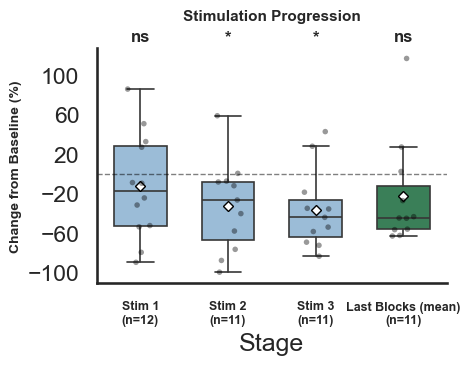

In [63]:
# 1. הגדרת רשימת השמות
subject_ids = ['485', '486', '487', '488', '489', '496', '497', '498', '499', '505', '5107', '515', '520', '538', '545']

# 2. עיבוד הנתונים
def prepare_data():
    exclude = ['515', '545']
    all_subjects_raw_pct = []
    raw_data = for_avg_props_raw['rates']['all']
    
    # 1. שלב ראשון: חישוב אחוזי שינוי לכל נבדק
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
        
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 2: continue
        
        baseline = subj_rates[0]
        if baseline == 0: continue
        
        # שליפת כל הבלוקים של הגירויים (Stim blocks)
        stims = subj_rates[1::2] 
        pct_changes = ((stims - baseline) / baseline) * 100
        
        # מוסיפים את הסדרה כפי שהיא - פנדס יטפל בהפרשי האורכים
        all_subjects_raw_pct.append(pd.Series(pct_changes))
    
    # הפיכה ל-DataFrame (כל שורה היא נבדק, כל עמודה היא בלוק)
    df_temp = pd.DataFrame(all_subjects_raw_pct)
    
    # 2. שלב שני: סינון חריגים (IQR) על כל עמודה (בלוק) בנפרד
    for col in df_temp.columns:
        Q1 = df_temp[col].quantile(0.25)
        Q3 = df_temp[col].quantile(0.75)
        IQR = Q3 - Q1
        # סינון לפי סף 3 (קיצוניים מאוד)
        df_temp.loc[(df_temp[col] < Q1 - 3*IQR) | (df_temp[col] > Q3 + 3*IQR), col] = np.nan
        
    # 3. שלב שלישי: בניית המטריצה הסופית עם המיצוע
    # לוקחים את 3 הבלוקים הראשונים ואת הממוצע של כל השאר (מבלוק 4 ואילך)
    final_data = {
        'Stim 1': df_temp[0],
        'Stim 2': df_temp[1],
        'Stim 3': df_temp[2],
        'Last Blocks (mean)': df_temp.iloc[:, 3:].mean(axis=1) 
    }
    
    df_wide = pd.DataFrame(final_data)
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    
    return df_wide, df_long

# 3. יצירת הגרף
def plot_final_graph(df_wide, df_long):
    plt.figure(figsize=(5, 4))
    sns.set_style("white")
    
    stim_blue = '#91bde1'  # הכחול שביקשת
    rest_green = '#2e8b57'
    
    # הכנת תוויות ציר X עם n
    new_labels = [f"{col}\n(n={df_wide[col].dropna().count()})" for col in df_wide.columns]
    
    # בוקספלוט
    ax = sns.boxplot(data=df_long, x='Stage', y='Change_Percent', 
                     palette=[stim_blue, stim_blue, stim_blue, rest_green],
                     width=0.6, fliersize=0, zorder=2, linewidth=1.2,
                     showmeans=True,
                     meanprops={"marker":"D", "markerfacecolor":"white", 
                                "markeredgecolor":"black", "markersize":5})
    
    # נקודות (Stripplot) - מוגדלות ל-4
    sns.stripplot(data=df_long, x='Stage', y='Change_Percent', 
                  color='black', alpha=0.4, size=4, jitter=0.15, ax=ax, zorder=3)
    
    # סטטיסטיקה - Wilcoxon
    y_max = df_long['Change_Percent'].max()
    for i in range(df_wide.shape[1]):
        data = df_wide.iloc[:, i].dropna()
        if len(data) >= 5:
            _, p_val = wilcoxon(data)
            stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            ax.text(i, y_max * 1.15, stars, ha='center', fontweight='bold', fontsize=12) # כוכביות גדולות

    # ציר Y מפורט יותר
    plt.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    y_min = df_long['Change_Percent'].min()
    ax.set_yticks(np.arange(int(y_min//20)*20, int(y_max//20 + 2)*20, 40))
    
    ax.set_xticklabels(new_labels, fontsize=9, fontweight='bold')
    plt.ylabel("Change from Baseline (%)", fontsize=10, fontweight='bold')
    plt.title("Stimulation Progression", fontsize=11, fontweight='bold', pad=20)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# --- הרצה סופית ---
df_w, df_l = prepare_data()
plot_final_graph(df_w, df_l)

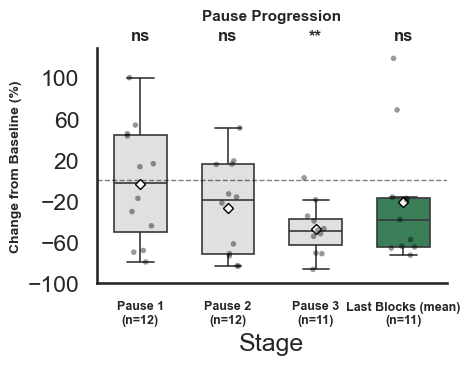

In [36]:

# 1. הגדרת רשימת השמות
subject_ids = ['485', '486', '487', '488', '489', '496', '497', '498', '499', '505', '5107', '515', '520', '538', '545']

# 2. עיבוד הנתונים למקטעי הפסקה (Pauses)
def prepare_pause_data():
    exclude = ['515', '545']
    all_subjects_processed = []
    raw_data = for_avg_props_raw['rates']['all']
    
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
            
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue # חייב לפחות בייסליין והפסקה ראשונה
        
        baseline = subj_rates[0]
        # שליפת ההפסקות: אינדקסים 2, 4, 6 (Pause 1, 2, 3)
        pauses = subj_rates[2::2] 
        
        if len(pauses) < 3: continue 
        
        denom = baseline if baseline != 0 else 1e-9
        pct_changes = ((pauses - baseline) / denom) * 100
        
        p1, p2, p3 = pct_changes[0], pct_changes[1], pct_changes[2]
        rest_remaining = pct_changes[3:]
        mean_rest = np.nanmean(rest_remaining) if len(rest_remaining) > 0 else np.nan
        
        all_subjects_processed.append([p1, p2, p3, mean_rest])
    
    stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks (mean)']
    df_wide = pd.DataFrame(all_subjects_processed, columns=stages)
    
    # סינון IQR (threshold=3)
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan

    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    return df_wide, df_long

# 3. יצירת הגרף
def plot_pause_graph(df_wide, df_long):
    plt.figure(figsize=(5, 4))
    sns.set_style("white")
    
    pause_gray = '#e0e0e0' # הצבע האפור שהשתמשנו בו להפסקות
    rest_green = '#2e8b57'
    
    new_labels = [f"{col}\n(n={df_wide[col].dropna().count()})" for col in df_wide.columns]
    
    # בוקספלוט
    ax = sns.boxplot(data=df_long, x='Stage', y='Change_Percent', 
                     palette=[pause_gray, pause_gray, pause_gray, rest_green],
                     width=0.6, fliersize=0, zorder=2, linewidth=1.2,
                     showmeans=True,
                     meanprops={"marker":"D", "markerfacecolor":"white", 
                                "markeredgecolor":"black", "markersize":5})
    
    # נקודות (Stripplot)
    sns.stripplot(data=df_long, x='Stage', y='Change_Percent', 
                  color='black', alpha=0.4, size=4, jitter=0.15, ax=ax, zorder=3)
    
    # סטטיסטיקה - Wilcoxon
    y_max = df_long['Change_Percent'].max()
    for i in range(df_wide.shape[1]):
        data = df_wide.iloc[:, i].dropna()
        if len(data) >= 5:
            _, p_val = wilcoxon(data)
            stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            ax.text(i, y_max * 1.15, stars, ha='center', fontweight='bold', fontsize=12)

    plt.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    # ציר Y
    y_min = df_long['Change_Percent'].min()
    ax.set_yticks(np.arange(int(y_min//20)*20, int(y_max//20 + 2)*20, 40))
    
    ax.set_xticklabels(new_labels, fontsize=9, fontweight='bold')
    plt.ylabel("Change from Baseline (%)", fontsize=10, fontweight='bold')
    plt.title("Pause Progression", fontsize=11, fontweight='bold', pad=20)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# --- הרצה ---
df_w_pause, df_l_pause = prepare_pause_data()
plot_pause_graph(df_w_pause, df_l_pause)

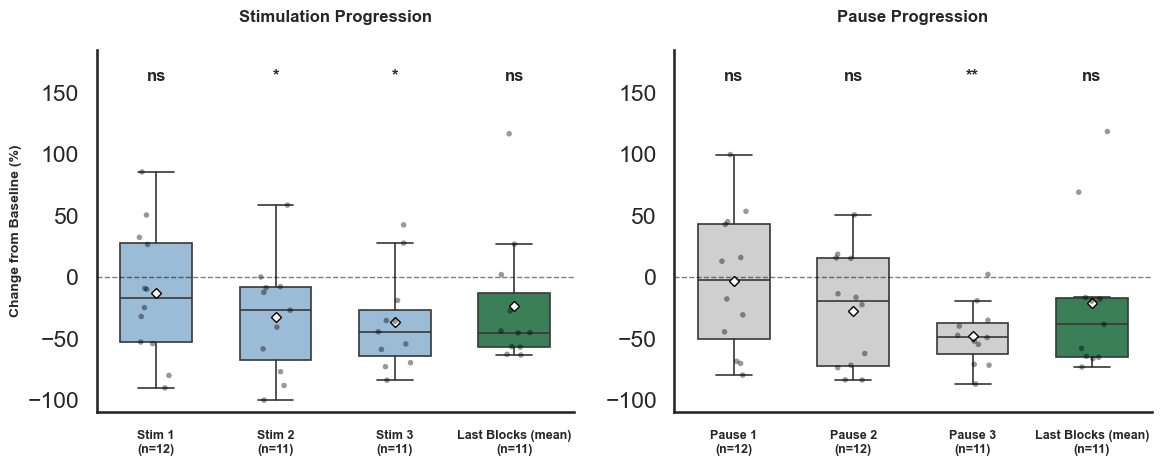

In [71]:
# 1. פונקציית עיבוד גנרית לנתונים מאוחדים (All)
def prepare_unified_data(block_type='stim'):
    exclude = ['515', '545']
    all_subjects_raw_pct = []
    # שימוש בנתוני 'all' כפי שביקשת
    raw_data = for_avg_props_raw['rates']['all']
    
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
        
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        if baseline == 0: continue
        
        # בחירת בלוקים: אי-זוגיים לגירוי, זוגיים להפסקה
        vals = subj_rates[1::2] if block_type == 'stim' else subj_rates[2::2]
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / baseline) * 100
        all_subjects_raw_pct.append(pd.Series(pct_changes))
    
    df_temp = pd.DataFrame(all_subjects_raw_pct)
    
    # שלב הסינון: IQR על כל בלוק בנפרד לפני המיצוע
    for col in df_temp.columns:
        Q1, Q3 = df_temp[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_temp.loc[(df_temp[col] < Q1 - 3*IQR) | (df_temp[col] > Q3 + 3*IQR), col] = np.nan
        
    # בניית השלבים הסופיים
    label_prefix = 'Stim' if block_type == 'stim' else 'Pause'
    final_dict = {
        f'{label_prefix} 1': df_temp[0],
        f'{label_prefix} 2': df_temp[1],
        f'{label_prefix} 3': df_temp[2],
        'Last Blocks (mean)': df_temp.iloc[:, 3:].mean(axis=1)
    }
    
    df_wide = pd.DataFrame(final_dict)
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    return df_wide, df_long

# 2. פונקציית הציור המשותפת
def plot_combined_unified_graphs():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.set_style("white")
    
    # צבעים
    stim_blue = '#91bde1'
    pause_gray = '#cfcfcf'
    last_blocks_color = '#2e8b57' # ירוק כפי שהיה בגרף המקורי שלך
    
    def draw_ax(ax, block_type):
        df_w, df_l = prepare_unified_data(block_type)
        
        # הגדרת פלטת צבעים: 3 בלוקים ראשונים בצבע המאפיין, והאחרון בירוק
        current_color = stim_blue if block_type == 'stim' else pause_gray
        pal = [current_color, current_color, current_color, last_blocks_color]
        
        # בוקספלוט
        sns.boxplot(data=df_l, x='Stage', y='Change_Percent', palette=pal,
                    width=0.6, fliersize=0, zorder=2, linewidth=1.2, ax=ax,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":5})
        
        # נקודות (Stripplot)
        sns.stripplot(data=df_l, x='Stage', y='Change_Percent', color='black', 
                      alpha=0.4, size=4, jitter=0.15, ax=ax, zorder=3)
        
        # סטטיסטיקה מול 0
        y_max = df_l['Change_Percent'].max()
        for i in range(df_w.shape[1]):
            data = df_w.iloc[:, i].dropna()
            if len(data) >= 5:
                _, p = wilcoxon(data)
                stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                # הצבת הכוכביות בגובה אחיד ומעט גבוה יותר
                ax.text(i, 160, stars, ha='center', fontweight='bold', fontsize=12)

        ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        # כותרות וצירים
        title = "Stimulation Progression" if block_type == 'stim' else "Pause Progression"
        ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=10, fontweight='bold')
        ax.set_xlabel("")
        
        # תוויות X עם n
        new_labels = [f"{col}\n(n={df_w[col].dropna().count()})" for col in df_w.columns]
        ax.set_xticklabels(new_labels, fontsize=9, fontweight='bold')
        
        # הגדרת ציר Y אחיד
        ax.set_ylim(-110, 185)
        ax.set_yticks(np.arange(-100, 151, 50))
        sns.despine(ax=ax)

    draw_ax(ax1, 'stim')
    draw_ax(ax2, 'pause')
    
    plt.tight_layout()
    plt.show()

# הרצה
plot_combined_unified_graphs()

C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\scipy\stats\_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\scipy\stats\_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


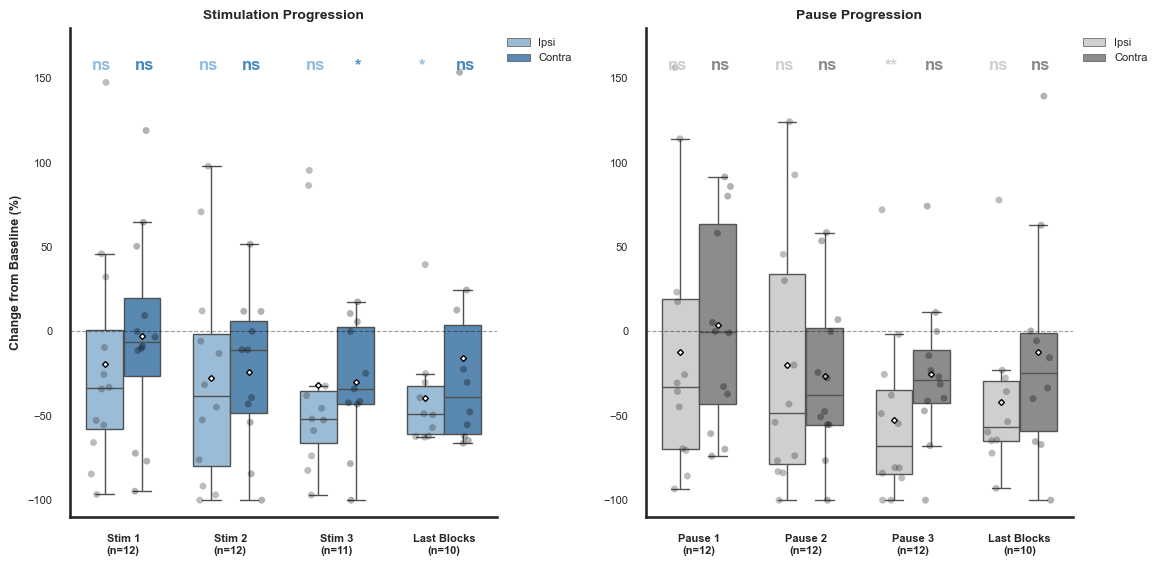

In [57]:
from scipy.stats import wilcoxon

def prepare_hemi_progression_data(hemi_type, block_type='stim'):
    all_subjects = []
    # שליפת הדאטה המתאים (ipsi או contra)
    raw_data = for_avg_props_raw['rates'][hemi_type]
    
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            # בלוקים 1, 3, 5
            vals = subj_rates[1::2]
            stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks (mean)']
        else:
            # בלוקים 2, 4, 6
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks (mean)']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # בניה של השורה: 3 בלוקים ראשונים וממוצע השאר
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # סינון IQR 3.0
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan
        
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Hemisphere'] = hemi_type.capitalize()
    return df_wide, df_long


def plot_combined_progression_final_v3():
    # יצירת פיגר רחב
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    sns.set_style("white")
    
    # גובה אחיד וגבוה יותר לסטטיסטיקה כדי למנוע דריסה
    y_stat_fixed = 155 
    
    def draw_on_ax(ax, block_type):
        hemi_types = ['ipsi', 'contra']
        df_list = []
        df_wide_dict = {}
        
        for h in hemi_types:
            df_w, df_l = prepare_hemi_progression_data(h, block_type)
            df_list.append(df_l)
            df_wide_dict[h.capitalize()] = df_w
            
        df_combined = pd.concat(df_list)
        
        if block_type == 'stim':
            pal = {'Ipsi': '#91bde1', 'Contra': '#4a89bf'}
            title = "Stimulation Progression"
        else:
            pal = {'Ipsi': '#cfcfcf', 'Contra': '#8c8c8c'}
            title = "Pause Progression"
            
        # בוקספלוט
        sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                    palette=pal, width=0.7, fliersize=0, zorder=2, linewidth=1,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":3}, ax=ax)
        
        sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                      dodge=True, color='black', alpha=0.3, size=2.5, jitter=0.2, ax=ax, zorder=3, s=5)
        
        # --- סטטיסטיקה בגובה אחיד למעלה ---
        offsets = [-0.2, 0.2]
        current_stages = df_combined['Stage'].unique()
        
        for i, stage in enumerate(current_stages):
            for h_idx, h_name in enumerate(['Ipsi', 'Contra']):
                data = df_wide_dict[h_name][stage].dropna()
                if len(data) >= 5:
                    _, p = wilcoxon(data)
                    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                    ax.text(i + offsets[h_idx], y_stat_fixed, stars, ha='center', 
                            fontsize=12, fontweight='bold', color=pal[h_name])

        ax.axhline(0, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
        
        # עיצוב צירים
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=9, fontweight='bold')
        
        # הסרת כותרת ציר X
        ax.set_xlabel("") 
        
        # תוויות X
        new_labels = []
        for stage in current_stages:
            n_val = df_wide_dict['Ipsi'][stage].dropna().count()
            label = stage.replace(" (mean)", "")
            new_labels.append(f"{label}\n(n={n_val})")
        ax.set_xticklabels(new_labels, fontsize=8, fontweight='bold')
        
        # הגדלת טווח ציר Y
        ax.set_ylim(-110, 180) 
        ax.set_yticks(np.arange(-100, 151, 50))
        ax.tick_params(labelsize=8)
        
        # מקרא מחוץ לגרף
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], labels[:2], title=None, fontsize=8, 
                  frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
        sns.despine(ax=ax)

    draw_on_ax(ax1, 'stim')
    draw_on_ax(ax2, 'pause')
    
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()

# הרצה
plot_combined_progression_final_v3()

C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\scipy\stats\_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\scipy\stats\_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


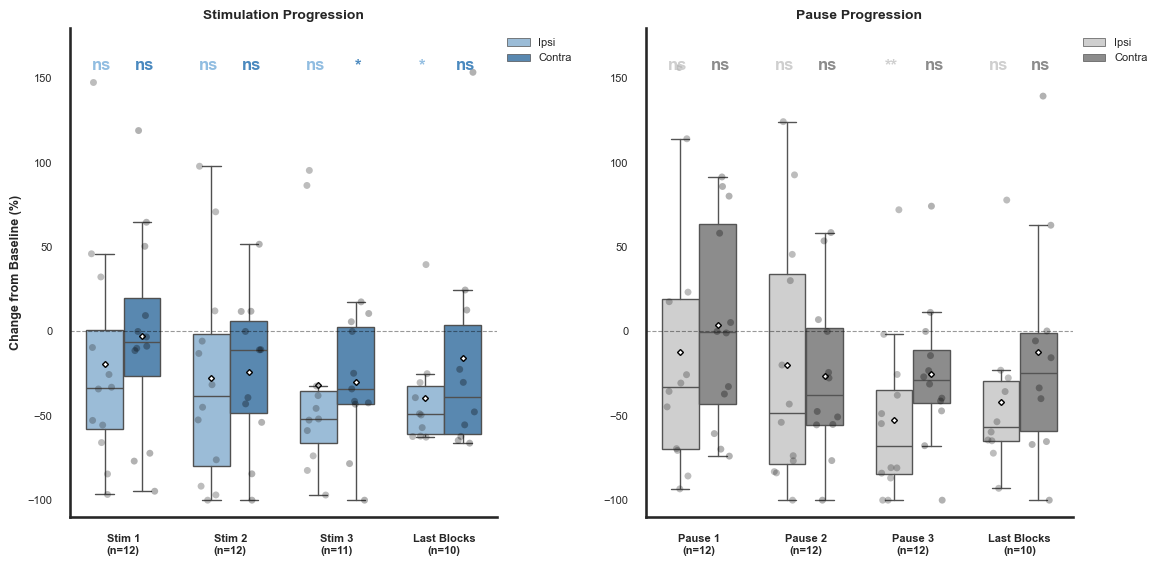

In [59]:
from scipy.stats import wilcoxon

def prepare_hemi_progression_data(hemi_type, block_type='stim'):
    all_subjects = []
    # שליפת הדאטה המתאים (ipsi או contra)
    raw_data = for_avg_props_raw['rates'][hemi_type]
    
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            # בלוקים 1, 3, 5
            vals = subj_rates[1::2]
            stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks (mean)']
        else:
            # בלוקים 2, 4, 6
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks (mean)']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # בניה של השורה: 3 בלוקים ראשונים וממוצע השאר
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # סינון IQR 3.0
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan
        
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Hemisphere'] = hemi_type.capitalize()
    return df_wide, df_long


def plot_combined_progression_final_v3():
    # יצירת פיגר רחב
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    sns.set_style("white")
    
    # גובה אחיד וגבוה יותר לסטטיסטיקה כדי למנוע דריסה
    y_stat_fixed = 155 
    
    def draw_on_ax(ax, block_type):
        hemi_types = ['ipsi', 'contra']
        df_list = []
        df_wide_dict = {}
        
        for h in hemi_types:
            df_w, df_l = prepare_hemi_progression_data(h, block_type)
            df_list.append(df_l)
            df_wide_dict[h.capitalize()] = df_w
            
        df_combined = pd.concat(df_list)
        
        if block_type == 'stim':
            pal = {'Ipsi': '#91bde1', 'Contra': '#4a89bf'}
            title = "Stimulation Progression"
        else:
            pal = {'Ipsi': '#cfcfcf', 'Contra': '#8c8c8c'}
            title = "Pause Progression"
            
        # בוקספלוט
        sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                    palette=pal, width=0.7, fliersize=0, zorder=2, linewidth=1,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":3}, ax=ax)
        
        sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                      dodge=True, color='black', alpha=0.3, size=2.5, jitter=0.2, ax=ax, zorder=3, s=5)
        
        # --- סטטיסטיקה בגובה אחיד למעלה ---
        offsets = [-0.2, 0.2]
        current_stages = df_combined['Stage'].unique()
        
        for i, stage in enumerate(current_stages):
            for h_idx, h_name in enumerate(['Ipsi', 'Contra']):
                data = df_wide_dict[h_name][stage].dropna()
                if len(data) >= 5:
                    _, p = wilcoxon(data)
                    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                    ax.text(i + offsets[h_idx], y_stat_fixed, stars, ha='center', 
                            fontsize=12, fontweight='bold', color=pal[h_name])

        ax.axhline(0, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
        
        # עיצוב צירים
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=9, fontweight='bold')
        
        # הסרת כותרת ציר X
        ax.set_xlabel("") 
        
        # תוויות X
        new_labels = []
        for stage in current_stages:
            n_val = df_wide_dict['Ipsi'][stage].dropna().count()
            label = stage.replace(" (mean)", "")
            new_labels.append(f"{label}\n(n={n_val})")
        ax.set_xticklabels(new_labels, fontsize=8, fontweight='bold')
        
        # הגדלת טווח ציר Y
        ax.set_ylim(-110, 180) 
        ax.set_yticks(np.arange(-100, 151, 50))
        ax.tick_params(labelsize=8)
        
        # מקרא מחוץ לגרף
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], labels[:2], title=None, fontsize=8, 
                  frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
        sns.despine(ax=ax)

    draw_on_ax(ax1, 'stim')
    draw_on_ax(ax2, 'pause')
    
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()

# הרצה
plot_combined_progression_final_v3()

In [82]:
import joblib
joblib.dump(for_avg_props_raw, 'for_avg_props_raw_stim.pkl')

['for_avg_props_raw_stim.pkl']